In [ ]:
# Montamos el drive para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/Lab_progra_DS/proyecto_MDS/competition_files/' # Ajustar al path propio
except:
    print('Ignorando conexión drive-colab')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1. EDA

## 1.1 Análisis General del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
data = pd.read_parquet(path + "X_t0.parquet")

# Revisar las dimensiones del dataset
print(f"Dimensiones del dataset: {data.shape}")

# Revisar los primeros registros
print("Primeros registros del dataset:")
display(data.head())

# Resumen de las variables
print("\nResumen general del dataset:")
display(data.info())

# Valores nulos por columna
print("\nValores nulos por columna:")
display(data.isnull().sum())

# Descripción estadística de las variables numéricas
print("\nDescripción estadística de las variables numéricas:")
display(data.describe())


Dimensiones del dataset: (44296, 77)
Primeros registros del dataset:


,borrow_block_number,borrow_timestamp,wallet_address,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,...,market_macdsignal,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count
0,7711117,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973049.0,199,438,-239,0.397391,...,1.212219,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1
1,7711123,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973188.0,200,439,-239,0.399063,...,1.212219,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1
2,7711126,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973238.0,201,440,-239,0.400895,...,1.212219,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1
3,7711672,1.557205e+09,0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6,1.557191e+09,1.557198e+09,13922.0,8,56,-48,0.604001,...,1.212219,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1
4,7712572,1.557217e+09,0xbd9ed130a53cfafcf81502e4d35329a6c4d53410,1.557217e+09,1.557217e+09,264.0,2,3,-1,0.003008,...,1.212219,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1



Resumen general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44296 entries, 0 to 44295
Data columns (total 77 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   borrow_block_number                      44296 non-null  int64  
 1   borrow_timestamp                         44296 non-null  float64
 2   wallet_address                           44296 non-null  object 
 3   first_tx_timestamp                       44296 non-null  float64
 4   last_tx_timestamp                        44296 non-null  float64
 5   wallet_age                               44296 non-null  float64
 6   incoming_tx_count                        44296 non-null  int64  
 7   outgoing_tx_count                        44296 non-null  int64  
 8   net_incoming_tx_count                    44296 non-null  int64  
 9   total_gas_paid_eth                       44296 non-null  float64
 10  avg_gas_paid_per

None


Valores nulos por columna:


,0
borrow_block_number,0
borrow_timestamp,0
wallet_address,0
first_tx_timestamp,0
last_tx_timestamp,0
...,...
market_ppo,0
market_rocp,0
market_rocr,0
unique_borrow_protocol_count,0



Descripción estadística de las variables numéricas:


,borrow_block_number,borrow_timestamp,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,avg_gas_paid_per_tx_eth,...,market_macdsignal,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count
count,4.429600e+04,4.429600e+04,4.429600e+04,4.429600e+04,4.429600e+04,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,...,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000,44296.000000
mean,9.343121e+06,1.579559e+09,1.550122e+09,1.579501e+09,2.943773e+07,999.369514,1360.256231,-360.886717,2.717345,0.002874,...,1.577302,-0.717461,5.533406,22.260178,34.435369,0.267880,-0.006844,0.993156,0.846758,0.970268
std,7.772108e+05,1.070282e+07,2.936277e+07,1.071609e+07,2.897753e+07,3065.153260,3936.526950,2167.545039,13.380028,0.008137,...,10.362093,0.064708,1.532826,9.163070,18.010626,8.010179,0.153774,0.153774,0.360225,0.169848
min,7.711117e+06,1.557197e+09,1.438270e+09,1.557197e+09,1.370000e+02,1.000000,0.000000,-68013.000000,0.000000,0.000000,...,-25.740436,-0.895911,3.089819,6.297847,5.413265,-29.248726,-0.545814,0.454186,0.000000,0.000000
25%,8.638256e+06,1.569687e+09,1.522918e+09,1.569553e+09,3.641601e+06,34.000000,52.000000,-198.000000,0.076647,0.000937,...,-6.681407,-0.736622,4.520733,15.789090,20.398524,-4.305614,-0.073433,0.926567,1.000000,1.000000
50%,9.470717e+06,1.581544e+09,1.558756e+09,1.581499e+09,1.900256e+07,134.000000,207.000000,-49.000000,0.349336,0.001550,...,4.145440,-0.736622,5.229391,19.489917,30.411080,0.303495,-0.011708,0.988292,1.000000,1.000000
75%,1.008743e+07,1.589770e+09,1.573658e+09,1.589671e+09,5.196818e+07,471.000000,678.000000,-8.000000,1.406124,0.002773,...,8.143114,-0.668565,6.303838,27.579281,43.521182,5.438241,0.072939,1.072939,1.000000,1.000000
max,1.033663e+07,1.593110e+09,1.593109e+09,1.593151e+09,1.540836e+08,98747.000000,71087.000000,97831.000000,506.170766,0.415178,...,24.356935,-0.565216,11.588088,56.729534,108.686030,19.424855,0.534402,1.534402,1.000000,1.000000


Ahora, uniremos los datos y las etiquetas para realizar un análisis más completo.

In [ ]:
# Cargar etiquetas
y_data = pd.read_parquet(path + "y_t0.parquet")

# Unir datos y etiquetas
data['target'] = y_data['target']

# Confirmar dimensiones tras la unión
print(f"Dimensiones del dataset combinado: {data.shape}")

# Revisar los primeros registros
print("Primeros registros del dataset combinado:")
display(data.head())

# Revisar el balance de la variable objetivo
print("\nDistribución de la variable objetivo (target):")
display(data['target'].value_counts(normalize=True))

# Valores nulos tras la unión
print("\nValores nulos por columna tras la unión:")
display(data.isnull().sum().sum())

Dimensiones del dataset combinado: (44296, 78)
Primeros registros del dataset combinado:


,borrow_block_number,borrow_timestamp,wallet_address,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,...,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count,target
0,7711117,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973049.0,199,438,-239,0.397391,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,1
1,7711123,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973188.0,200,439,-239,0.399063,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
2,7711126,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973238.0,201,440,-239,0.400895,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
3,7711672,1.557205e+09,0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6,1.557191e+09,1.557198e+09,13922.0,8,56,-48,0.604001,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0
4,7712572,1.557217e+09,0xbd9ed130a53cfafcf81502e4d35329a6c4d53410,1.557217e+09,1.557217e+09,264.0,2,3,-1,0.003008,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0



Distribución de la variable objetivo (target):


,proportion
target,
1,0.511468
0,0.488532



Valores nulos por columna tras la unión:


0

Confirmamos que la variable objetivo tampoco presneta datos nulos, excelente.

Ademas tenemos un par de clases balanceadas represtando ambas un 50% de la totalidad practicamante.

### Añadiendo X_t1 y y_t1

In [ ]:
#Cargar datos
# Cargar el dataset
data_1 = pd.read_parquet(path + "X_t1_v2.parquet")

# Cargar etiquetas
y_data_1 = pd.read_parquet(path + "y_t1.parquet")

# Reset the index of y_data_1['target'] to ensure unique values
y_data_1 = y_data_1.reset_index(drop=True)

# Reset the index of data_1 to ensure unique values
data_1 = data_1.reset_index(drop=True)

# Unir datos y etiquetas
data_1['target'] = y_data_1['target']

# Confirmar dimensiones tras la unión
print(f"Dimensiones del dataset combinado: {data_1.shape}")

# Revisar los primeros registros
print("Primeros registros del dataset combinado:")
display(data_1.head())

# Revisar el balance de la variable objetivo
print("\nDistribución de la variable objetivo (target):")
display(data_1['target'].value_counts(normalize=True))

# Valores nulos tras la unión
print("\nValores nulos por columna tras la unión:")
display(data_1.isnull().sum().sum())

Dimensiones del dataset combinado: (132888, 78)
Primeros registros del dataset combinado:


,borrow_block_number,borrow_timestamp,wallet_address,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,...,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count,target
0,10336632,1.593110e+09,0x585bb700e2cdb34e8857bcf156df116636992825,1.551772e+09,1.593110e+09,41337993.0,12,14,-2,0.015177,...,-0.736622,4.385686,19.552328,24.502158,-1.672639,0.007081,1.007081,0,0,0
1,10336644,1.593110e+09,0x2d0b0664d55ddc851561678bbe97d538ae78ed72,1.565473e+09,1.593110e+09,27637657.0,189,217,-28,1.162723,...,-0.736622,4.385686,19.552328,24.502158,-1.672639,0.007081,1.007081,1,1,0
2,10336670,1.593111e+09,0x25f810cd651e4de4814f519a0ad27c5e7a50338d,1.496321e+09,1.593106e+09,96789742.0,27,32,-5,0.270085,...,-0.736622,4.385686,19.552328,24.502158,-1.672639,0.007081,1.007081,1,1,0
3,10336675,1.593111e+09,0xd09051f120a79abe6c706285810cb8c199e1ce65,1.563614e+09,1.593110e+09,29496551.0,171,228,-57,0.206756,...,-0.736622,4.385686,19.552328,24.502158,-1.672639,0.007081,1.007081,0,1,0
4,10336679,1.593111e+09,0xc68914cb0fbd2ae5888035abe36aa3bc8722ac7c,1.593109e+09,1.593111e+09,1339.0,4,3,1,0.010250,...,-0.736622,4.385686,19.552328,24.502158,-1.672639,0.007081,1.007081,0,1,1



Distribución de la variable objetivo (target):


,proportion
target,
0,0.621915
1,0.378085



Valores nulos por columna tras la unión:


0

In [ ]:
# Concatenamos los datos verticamlmente
combined_data = pd.concat([data, data_1], ignore_index=True)

# Chequear las dimensiones
print(f"Shape of combined DataFrame: {combined_data.shape}")

# Ver los primeros registros
combined_data.head()

Shape of combined DataFrame: (177184, 78)


,borrow_block_number,borrow_timestamp,wallet_address,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,...,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count,target
0,7711117,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973049.0,199,438,-239,0.397391,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,1
1,7711123,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973188.0,200,439,-239,0.399063,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
2,7711126,1.557197e+09,0x502cb8985b2c92a8d4bf309cdaa89de9be442708,1.537224e+09,1.557197e+09,19973238.0,201,440,-239,0.400895,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,1,1,1
3,7711672,1.557205e+09,0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6,1.557191e+09,1.557198e+09,13922.0,8,56,-48,0.604001,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0
4,7712572,1.557217e+09,0xbd9ed130a53cfafcf81502e4d35329a6c4d53410,1.557217e+09,1.557217e+09,264.0,2,3,-1,0.003008,...,-0.895911,4.479356,33.216622,33.415526,-2.370346,0.104294,1.104294,0,1,0


In [ ]:
assert combined_data.shape[0] == data.shape[0] + data_1.shape[0]

Y el data de prueba

In [ ]:
X_t2 = pd.read_parquet(path + 'X_t2.parquet')

## 1.2 Análisis Estadístico y Distribuciones

In [ ]:
# Descripción estadística general
print("Descripción estadística general:")
display(combined_data.describe())

# Descripción estadística separada por target
print("\nDescripción estadística por grupo de 'target':")
display(combined_data.groupby('target').describe())


Descripción estadística general:


,borrow_block_number,borrow_timestamp,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,avg_gas_paid_per_tx_eth,...,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count,target
count,1.771840e+05,1.771840e+05,1.771840e+05,1.771840e+05,1.771840e+05,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,...,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000,177184.000000
mean,1.095034e+07,1.601196e+09,1.570760e+09,1.601128e+09,3.043543e+07,845.917442,1398.878934,-552.961492,18.886369,0.014749,...,-0.634117,4.830383,25.941209,623.853973,4.714216,0.079227,1.079227,0.943742,1.137992,0.411431
std,1.128040e+06,1.518864e+07,3.682310e+07,1.518256e+07,3.420357e+07,2738.925189,11471.208477,10853.264763,115.175063,0.030983,...,0.120238,1.145328,9.034135,7274.080546,8.030703,0.181272,0.181272,0.480319,0.382228,0.492094
min,7.711117e+06,1.557197e+09,1.438270e+09,1.557197e+09,1.370000e+02,1.000000,0.000000,-994655.000000,0.000000,0.000000,...,-0.895911,2.842363,6.297847,5.413265,-29.248726,-0.545814,0.454186,0.000000,0.000000,0.000000
25%,1.033663e+07,1.593110e+09,1.545374e+09,1.593084e+09,4.057024e+06,43.000000,59.000000,-233.000000,0.337762,0.003556,...,-0.668565,4.142814,18.975085,40.292288,-0.842135,-0.028410,0.971590,1.000000,1.000000,0.000000
50%,1.132544e+07,1.606279e+09,1.583632e+09,1.606219e+09,1.525050e+07,167.000000,242.000000,-58.000000,1.795153,0.010217,...,-0.668490,4.576816,24.986677,120.375087,4.698189,0.061657,1.061657,1.000000,1.000000,0.000000
75%,1.182610e+07,1.612925e+09,1.599236e+09,1.612837e+09,4.880033e+07,585.000000,833.000000,-8.000000,9.642788,0.018195,...,-0.654553,5.388576,30.880405,441.964585,9.149384,0.163194,1.163194,1.000000,1.000000,1.000000
max,1.233130e+07,1.619645e+09,1.619633e+09,1.619644e+09,1.813362e+08,197105.000000,996084.000000,195555.000000,3980.331914,2.586824,...,-0.361351,11.588088,56.729534,149188.000000,28.435216,0.768294,1.768294,2.000000,2.000000,1.000000



Descripción estadística por grupo de 'target':


borrow_block_number                                                     \
                     count          mean           std        min         25%   
target                                                                          
0                 104285.0  1.106458e+07  1.067000e+06  7711672.0  10415899.0   
1                  72899.0  1.078690e+07  1.191126e+06  7711117.0  10111885.5   

                                           borrow_timestamp                \
               50%         75%         max            count          mean   
target                                                                      
0       11444794.0  11857522.0  12331299.0         104285.0  1.602731e+09   
1       11046386.0  11779359.0  12331297.0          72899.0  1.598999e+09   

        ... unique_borrow_protocol_count      unique_lending_protocol_count  \
        ...                          75%  max                         count   
target  ...                                                                   
0       ...                          1.0  2.0                      104285.0   
1       ...                          1.0  2.0                       72899.0   

                                                     
            mean       std  min  25%  50%  75%  max  
target                                               
0       1.144374  0.387220  0.0  1.0  1.0  1.0  2.0  
1       1.128863  0.374784  0.0  1.0  1.0  1.0  2.0  

[2 rows x 608 columns]

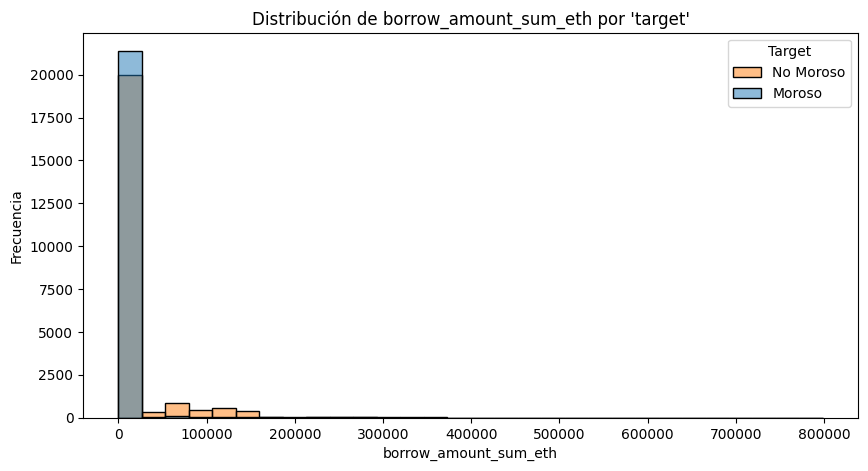

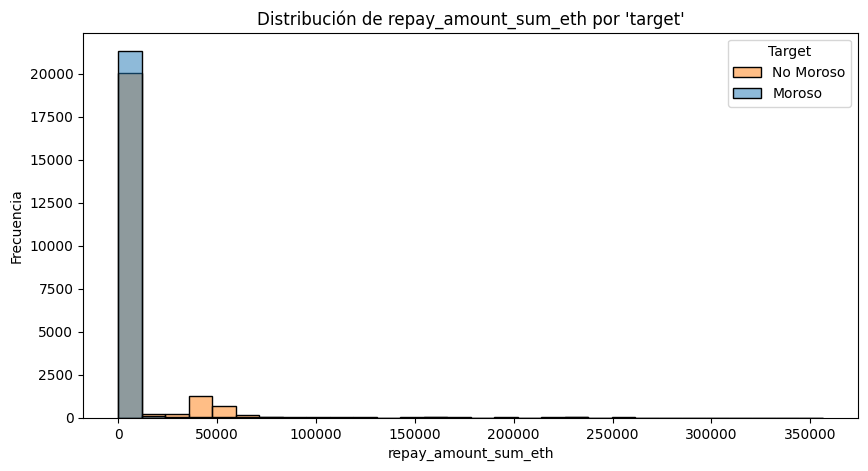

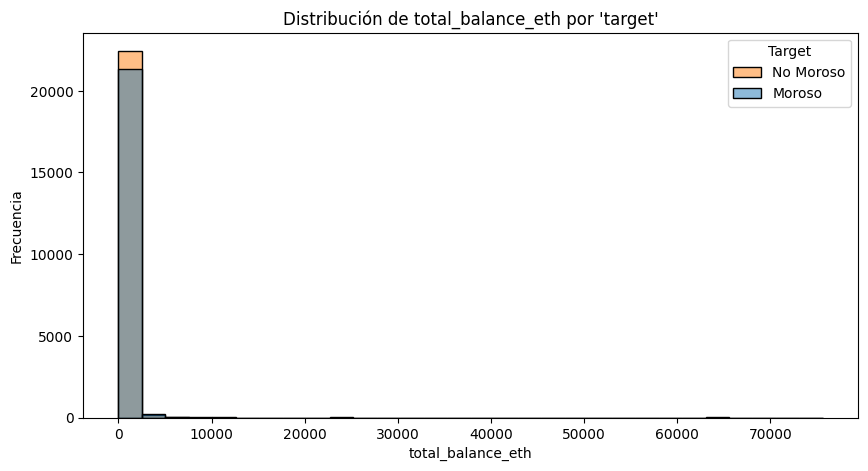

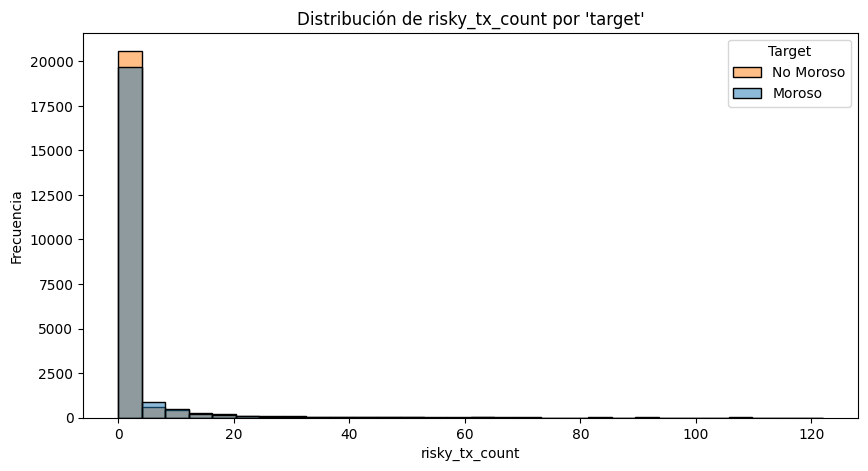

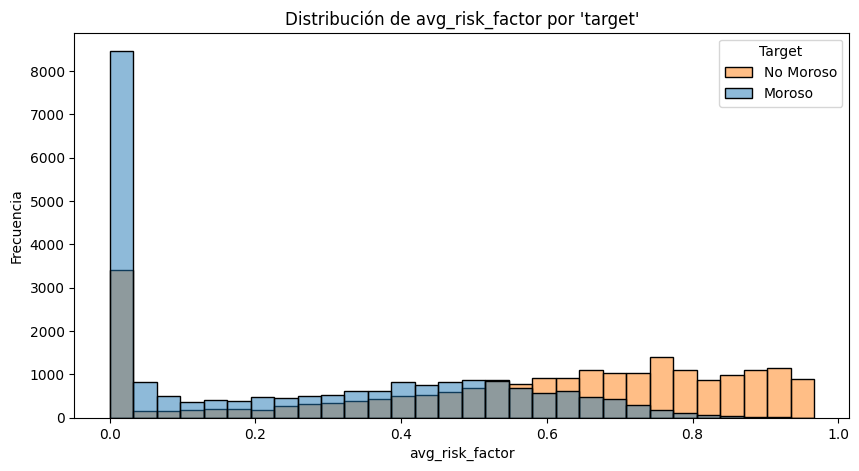

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se eligen algunas variables interesantes para explorar
variables = [
    'borrow_amount_sum_eth', 'repay_amount_sum_eth',
    'total_balance_eth', 'risky_tx_count', 'avg_risk_factor'
]

for var in variables:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=data, x=var, hue='target', bins=30)
    plt.title(f"Distribución de {var} por 'target'")
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend(title='Target', labels=['No Moroso', 'Moroso'])
    plt.show()

La forma poco informativa de los  primeros histogramas nos indica la presencia e outliers para estas variables. Por otro lado, para el histograma avg_risk_factor es interesnate ver que la mayoria de acciones riesgosas son tomadas por clientes no morosos.

Vizualisemos los outliers de las cariables anteriores con boxplots:

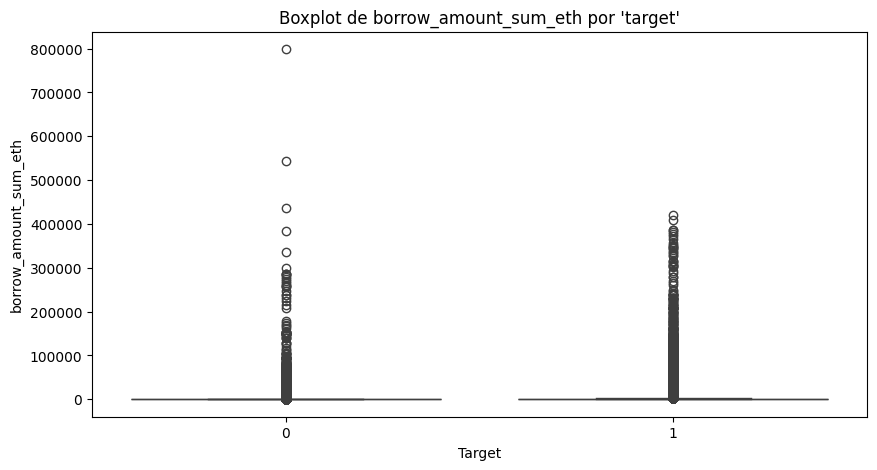

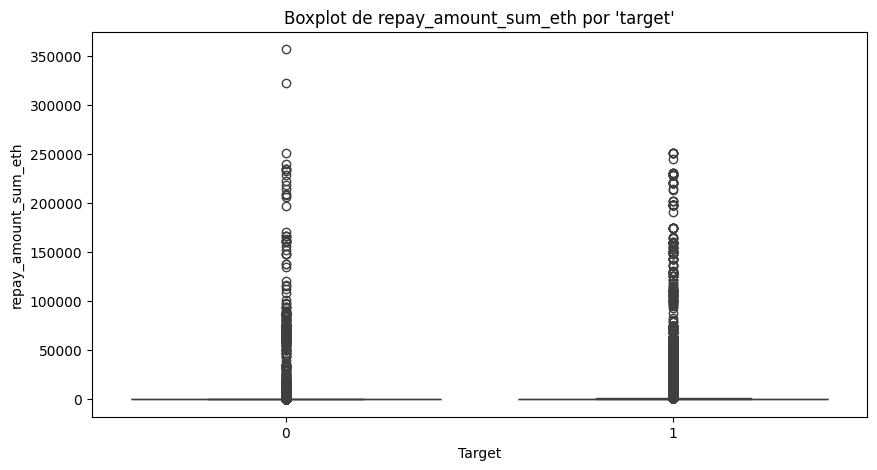

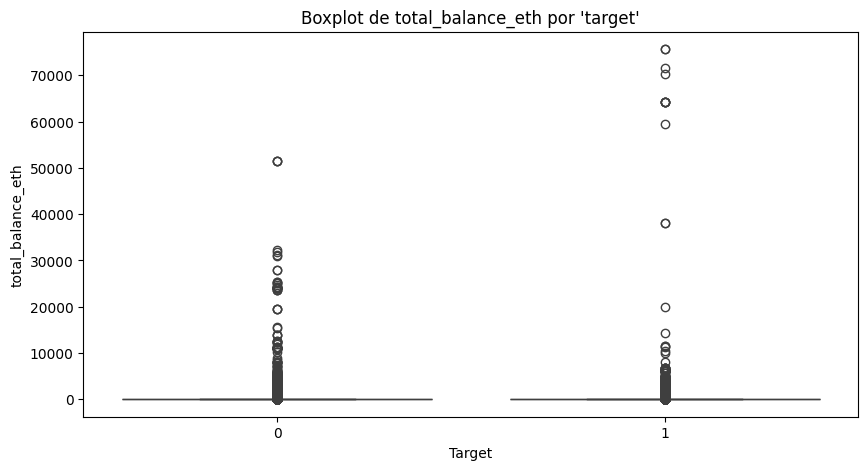

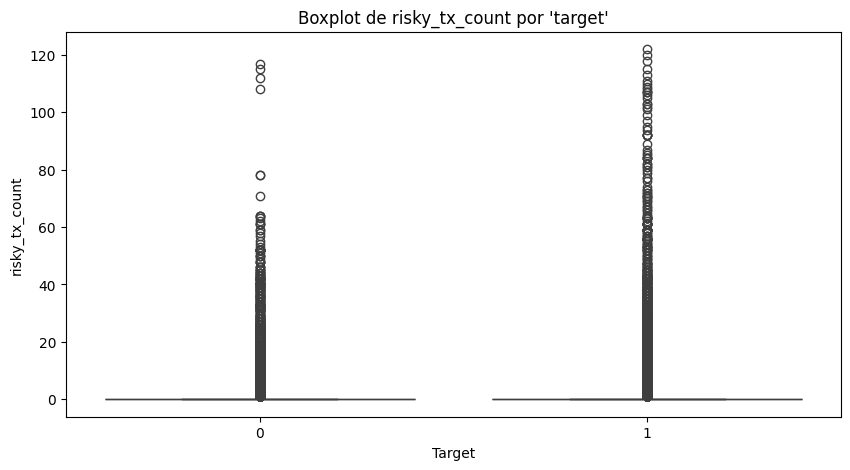

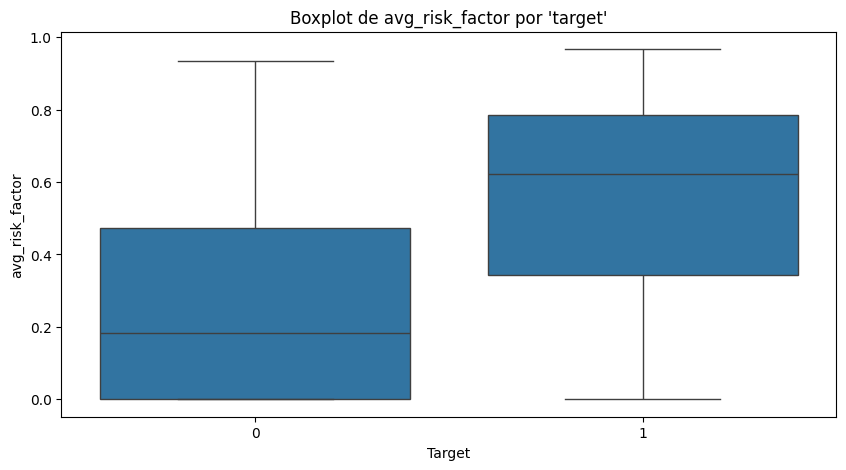

In [ ]:
for var in variables:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=data, x='target', y=var)
    plt.title(f"Boxplot de {var} por 'target'")
    plt.xlabel('Target')
    plt.ylabel(var)
    plt.show()

Claramente los otliers deben ser tratados para las 4 primeras variables, asi como para todas las variables del dataset en general. 'avg_risk_factor' es claramente una variable construida a partir de otras por lo que ya esta tratada y nos da informacion relevante.

In [ ]:
import numpy as np
import pandas as pd

def replace_extremes_with_percentiles(series):
    """Replaces values below 1st percentile and above 99th percentile
    with the respective percentile values.

    Args:
        series (pd.Series): The data series to process.

    Returns:
        pd.Series: The processed data series with extremes replaced.
    """

    # Calculate the 1st and 99th percentiles
    lower_limit = series.quantile(0.01)
    upper_limit = series.quantile(0.99)

    # Replace extreme values with the calculated percentiles
    series = series.clip(lower=lower_limit, upper=upper_limit)
    # or use np.clip: series = np.clip(series, lower_limit, upper_limit)

    return series


def handle_outliers_with_percentiles(df, columns_to_treat):
    """Applies extreme replacement to specified columns of a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to process.
        columns_to_treat (list): List of column names to treat.

    Returns:
        pd.DataFrame: The processed DataFrame with extremes replaced.
    """

    df_treated = df.copy()
    for col in columns_to_treat:
        df_treated[col] = replace_extremes_with_percentiles(df_treated[col])
    return df_treated

# Lista de columnas continuas relacionadas con ETH
columns_eth = [
    'total_gas_paid_eth', 'avg_gas_paid_per_tx_eth', 'incoming_tx_sum_eth',
    'outgoing_tx_avg_eth', 'max_eth_ever', 'min_eth_ever', 'total_balance_eth'
]

# Lista de columnas temporales y de conteo
columns_temporal_count = [
    'wallet_age', 'net_incoming_tx_count', 'risky_tx_count',
    'risky_first_last_tx_timestamp_diff'
]

# Variables del mercado
columns_market = [
    'market_adxr', 'market_atr', 'market_cci', 'market_dx',
    'market_aroonosc', 'market_plus_di'
]

# Para evitar Data leakege, aplicaremos este tratamiento para los outliers despues de separar nuestros datos en train y test

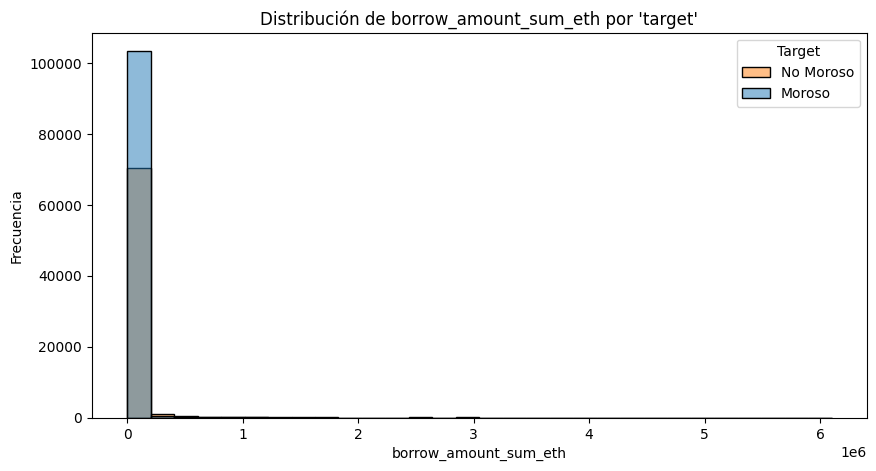

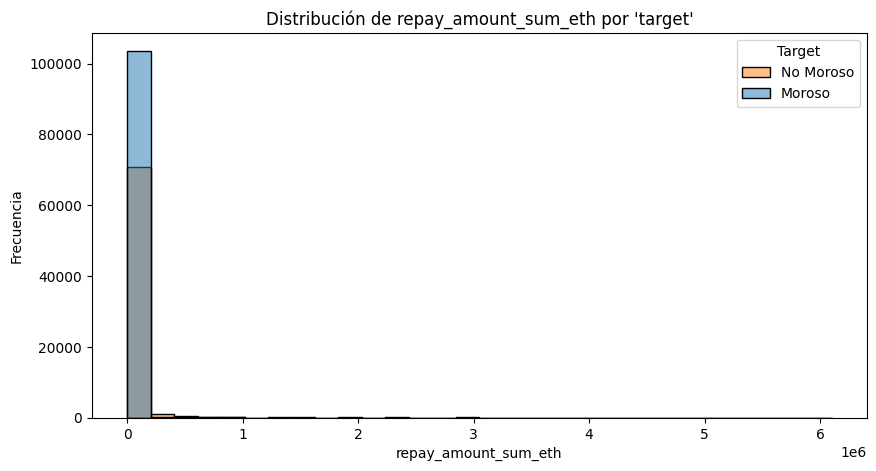

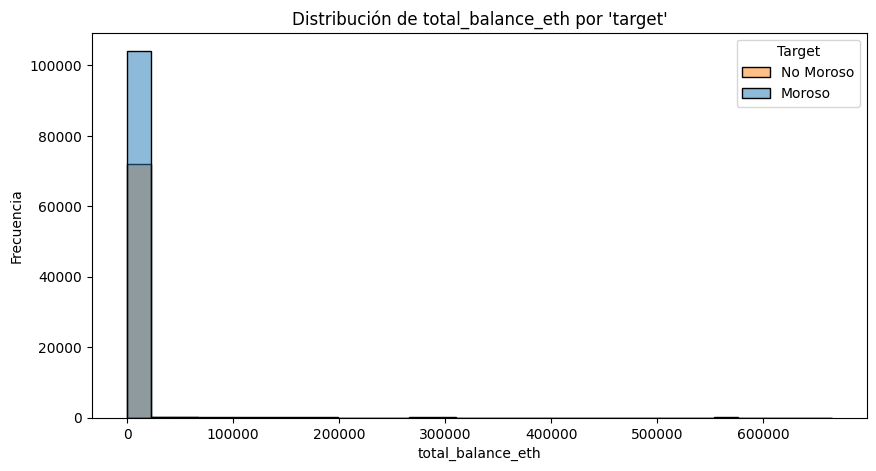

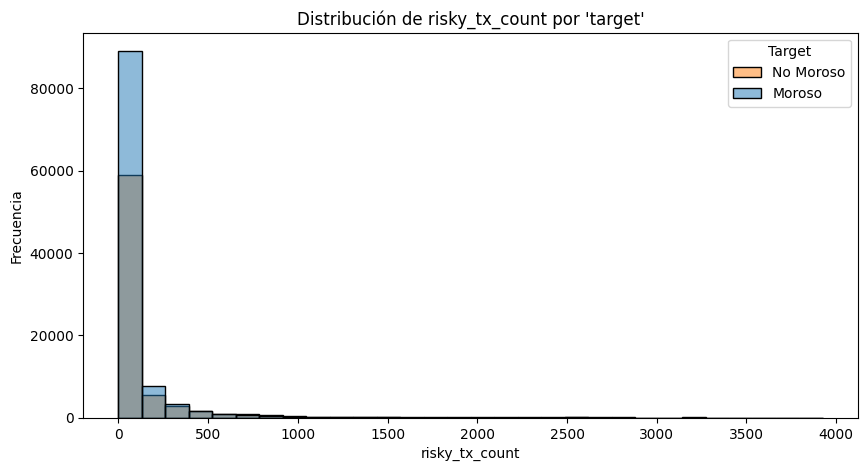

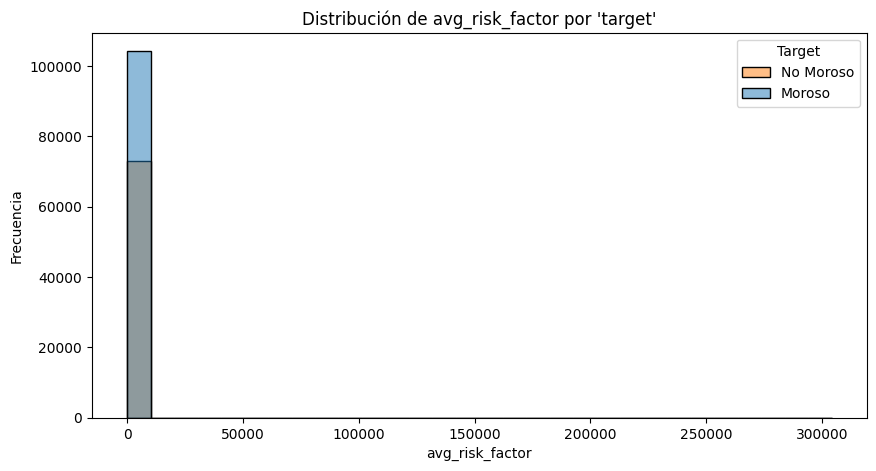

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se eligen algunas variables interesantes para explorar
variables = [
    'borrow_amount_sum_eth', 'repay_amount_sum_eth',
    'total_balance_eth', 'risky_tx_count', 'avg_risk_factor'
]

for var in variables:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=combined_data, x=var, hue='target', bins=30)
    plt.title(f"Distribución de {var} por 'target'")
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend(title='Target', labels=['No Moroso', 'Moroso'])
    plt.show()

Pd_1: Según entiendo, capping mantiene los outliers de forma 'controlada'. Por lo que apenas perderíamos información de los extremos de las distribuciones.

Winsorizing sirve para limitar valores extremos a percentiles específicos (sin eliminarlos por completo).

Por otra parte, igual hay varias distribuciones sesgadas a la izquierda, como borrow o repay amounts (e imagino varias más). Aquí podría ser más útil aplicar una transformación logarítmica.

Pd_2: Aunque el tratamiento de outliers es muy importante para varios modelos como regresión logística o SVM, para modelos basados en árboles no influye mucho si hay outlier o no.


## Variables timestamp

Tal parece ser que las variables timestamp estan en tiempo unix. Pasemosla a datatieme

In [ ]:
# Identificar columnas con formato UNIX (grandes números)
unix_columns = []
for col in combined_data.columns:
    if pd.api.types.is_numeric_dtype(combined_data[col]):
        # Verificar si los valores parecen ser timestamps UNIX
        if combined_data[col].min() > 1e9 and combined_data[col].max() < 1e12:  # Rango típico para UNIX en segundos
            unix_columns.append(col)

print("Columnas en formato UNIX identificadas:", unix_columns)

# Convertir las columnas identificadas a datetime
for col in unix_columns:
    combined_data[col] = pd.to_datetime(combined_data[col], unit='s')

# Validar las conversiones
print(combined_data[unix_columns].head())


Columnas en formato UNIX identificadas: ['borrow_timestamp', 'first_tx_timestamp', 'last_tx_timestamp']
     borrow_timestamp  first_tx_timestamp   last_tx_timestamp
0 2019-05-07 02:48:28 2018-09-17 22:44:19 2019-05-07 02:44:34
1 2019-05-07 02:50:47 2018-09-17 22:44:19 2019-05-07 02:48:28
2 2019-05-07 02:51:37 2018-09-17 22:44:19 2019-05-07 02:50:47
3 2019-05-07 04:55:33 2019-05-07 01:03:31 2019-05-07 02:52:25
4 2019-05-07 08:20:08 2019-05-07 08:15:44 2019-05-07 08:19:14


Funcion que identifica las variables en UNIX y los pasa a datime

In [ ]:
#Para el data X_t2

# Convertir las columnas identificadas a datetime
for col in unix_columns:
    X_t2[col] = pd.to_datetime(X_t2[col], unit='s')

# Validar las conversiones
print(X_t2[unix_columns].head())

          borrow_timestamp  first_tx_timestamp   last_tx_timestamp
177184 2021-04-28 21:16:48 2020-08-22 02:56:49 2021-04-28 21:14:17
177185 2021-04-28 21:20:17 2021-02-04 04:07:01 2021-04-28 06:36:51
177186 2021-04-28 21:21:17 2021-03-18 13:06:29 2021-04-28 20:31:42
177187 2021-04-28 21:22:53 2020-08-22 02:56:49 2021-04-28 21:19:20
177188 2021-04-28 21:23:48 2021-02-04 04:07:01 2021-04-28 21:22:02


In [ ]:
display(combined_data[unix_columns].sample(10))

,borrow_timestamp,first_tx_timestamp,last_tx_timestamp
155735,2021-03-21 22:12:40,2020-07-20 03:48:19,2021-03-21 22:11:57
4629,2019-07-24 17:48:17,2019-07-20 10:51:27,2019-07-23 17:54:49
42047,2020-06-22 16:58:57,2018-11-28 20:06:51,2020-06-22 16:56:02
25382,2020-03-06 18:14:48,2018-11-14 05:36:20,2020-03-06 16:43:52
98659,2020-12-20 22:35:05,2020-11-19 22:47:11,2020-12-20 22:34:08
105174,2021-01-02 13:25:46,2020-08-09 10:09:20,2021-01-02 13:24:11
37819,2020-06-19 15:06:14,2020-06-16 15:39:13,2020-06-19 11:06:27
114016,2021-01-14 17:28:00,2020-07-24 18:40:43,2021-01-14 00:08:10
170180,2021-04-21 12:51:32,2021-04-12 10:18:20,2021-04-21 12:50:39
24147,2020-02-25 17:38:30,2020-02-10 18:30:35,2020-02-25 17:31:41


In [ ]:
# Crear características basadas en las columnas de fechas
combined_data['duration_between_tx'] = (combined_data['last_tx_timestamp'] - combined_data['first_tx_timestamp']).dt.total_seconds()/3600 # En  horas
combined_data['days_since_borrow'] = (combined_data['borrow_timestamp'] - combined_data['first_tx_timestamp']).dt.days
combined_data['days_since_last_tx'] = (combined_data['last_tx_timestamp'] - combined_data['borrow_timestamp']).dt.days

# Verificar las nuevas características
print(combined_data[['duration_between_tx', 'days_since_borrow', 'days_since_last_tx']].head())

   duration_between_tx  days_since_borrow  days_since_last_tx
0          5548.004167                231                  -1
1          5548.069167                231                  -1
2          5548.107778                231                  -1
3             1.815000                  0                  -1
4             0.058333                  0                  -1


In [ ]:
# Lo mimso que la celda anterior, pero para X_t2
X_t2['duration_between_tx'] = (X_t2['last_tx_timestamp'] - X_t2['first_tx_timestamp']).dt.total_seconds()/3600 # En  horas
X_t2['days_since_borrow'] = (X_t2['borrow_timestamp'] - X_t2['first_tx_timestamp']).dt.days
X_t2['days_since_last_tx'] = (X_t2['last_tx_timestamp'] - X_t2['borrow_timestamp']).dt.days

print(X_t2[['duration_between_tx', 'days_since_borrow', 'days_since_last_tx']].head())

        duration_between_tx  days_since_borrow  days_since_last_tx
177184          5994.291111                249                  -1
177185          1994.497222                 83                  -1
177186           991.420278                 41                  -1
177187          5994.375278                249                  -1
177188          2009.250278                 83                  -1


In [ ]:
#Eliminar las variables originales
combined_data.drop(columns=unix_columns, inplace=True)

In [ ]:
X_t2.drop(columns=unix_columns, inplace=True)

In [ ]:
import pandas as pd

def convertir_unix_a_datetime(df):
    """
    Identifica y convierte las columnas con marcas de tiempo UNIX a objetos datetime.
    """
    columnas_unix = []
    for columna in df.columns:
        if pd.api.types.is_numeric_dtype(df[columna]):
            # Verificar si los valores parecen ser timestamps UNIX
            if df[columna].min() > 1e9 and df[columna].max() < 1e12:
                columnas_unix.append(columna)

    # Convertir a datetime
    for columna in columnas_unix:
        df[columna] = pd.to_datetime(df[columna], unit='s')

    return df, columnas_unix  # Devolver columnas_unix para usarlas en la siguiente función

def crear_caracteristicas_diferencia_tiempo(df, columnas_unix):
    """
    Crea características de diferencia de tiempo y elimina las columnas originales de marcas de tiempo.
    """
    # Crear nuevas características
    df['duration_between_tx'] = (df['last_tx_timestamp'] - df['first_tx_timestamp']).dt.total_seconds() / 3600
    df['days_since_borrow'] = (df['borrow_timestamp'] - df['first_tx_timestamp']).dt.days
    df['days_since_last_tx'] = (df['last_tx_timestamp'] - df['borrow_timestamp']).dt.days

    # Eliminar las columnas originales de marcas de tiempo
    df.drop(columns=columnas_unix, inplace=True)

    return df

def procesar_marcas_tiempo(df):
    """
    Convierte marcas de tiempo UNIX a datetime y crea características de diferencia de tiempo.
    """
    df, columnas_unix = convertir_unix_a_datetime(df)  # Obtener columnas_unix
    df = crear_caracteristicas_diferencia_tiempo(df, columnas_unix)
    return df

# Ejemplo de uso:
datos_procesados = procesar_marcas_tiempo(combined_data)

In [ ]:
X_t2_procesados = procesar_marcas_tiempo(X_t2)

Variables originales:
* borrow_timestamp:
Representa la fecha y hora en la que se realizó un préstamo.
* first_tx_timestamp:
Representa la fecha y hora de la primera transacción registrada para la billetera.
* last_tx_timestamp:
Representa la fecha y hora de la última transacción registrada para la billetera.

Nuevas variables propuestas:

* duration_between_tx:
Cálculo: $\text{last_tx_timestamp} - \text{first_tx_timestamp}$

Interpretación:
Es el tiempo total (en segundos) que transcurrió entre la primera y la última transacción de la billetera.
Esta variable puede ser útil para medir la actividad histórica de la cuenta en términos de tiempo.

* days_since_borrow:

Cálculo: $\text{borrow_timestamp} - \text{first_tx_timestamp}$

Interpretación:
Es el número de días que pasaron desde la primera transacción registrada hasta el momento en que se realizó el préstamo.
Una billetera que solicitó un préstamo muy poco después de crearse podría ser más riesgosa que una con un historial más largo.

* days_since_last_tx:

Cálculo: $\text{last_tx_timestamp} - \text{borrow_timestamp}$

Interpretación:
Es el número de días que pasaron desde que se solicitó el préstamo hasta la última transacción registrada.
Esto puede indicar si la billetera ha estado activa o inactiva desde el préstamo, lo que podría correlacionarse con el riesgo de incumplimiento.


In [ ]:
# Ver la cantidad por cada clase
display(datos_procesados.days_since_last_tx.value_counts('%')), display(datos_procesados.days_since_borrow.value_counts('%'))

,proportion
days_since_last_tx,
-1,0.877455
-2,0.045478
-3,0.021836
-4,0.012795
-5,0.008251
...,...
-185,0.000006
-140,0.000006
-209,0.000006


,proportion
days_since_borrow,
0,0.042978
1,0.012433
2,0.009843
3,0.007924
4,0.006914
...,...
1521,0.000006
1604,0.000006
1805,0.000006


(None, None)

days_since_borrow parace ser negativa. Esto es asi porque  la columna borrow_timestamp generalmente ocurre en la misma fecha que last_tx_timestamp, pero con una diferencia en horas, minutos o segundos, lo que sugiere que el préstamo ocurre poco después de la última transacción (para la gran mayoria de datos). Esto parece lógico en el flujo de eventos de los datos, ya que probablemente el préstamo se registra como una transacción cercana en el tiempo.

Sin embargo, hay casos anómalos con diferencias negativas significativas (incluso menos que -100 días), lo que indica una posible desincronización o anomalía en los datos

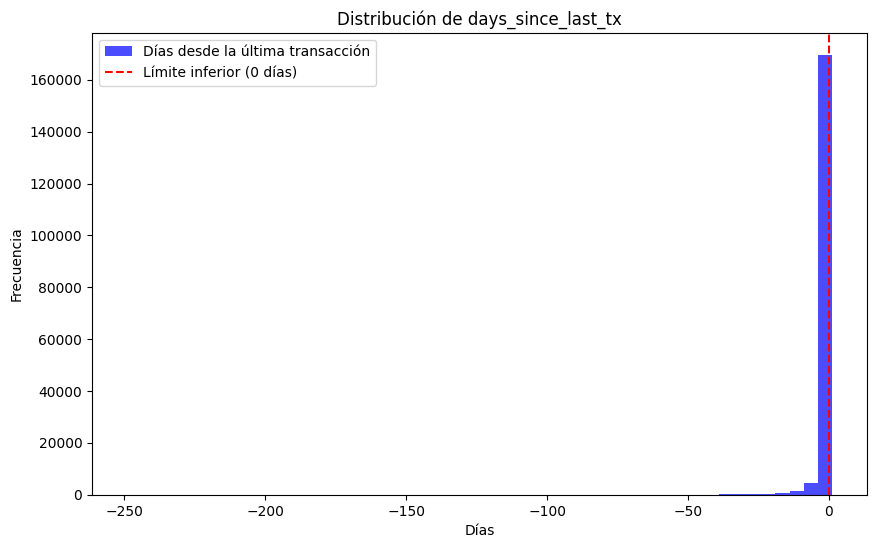

Porcentaje de valores negativos: 100.00%


In [ ]:
import matplotlib.pyplot as plt

# Histogramas
plt.figure(figsize=(10, 6))
plt.hist(datos_procesados['days_since_last_tx'], bins=50, alpha=0.7, color='blue', label='Días desde la última transacción')
plt.axvline(x=0, color='red', linestyle='--', label='Límite inferior (0 días)')
plt.title('Distribución de days_since_last_tx')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Porcentaje de valores negativos
neg_percentage = (datos_procesados['days_since_last_tx'] < 0).mean() * 100
print(f"Porcentaje de valores negativos: {neg_percentage:.2f}%")

Parecen ser muy pocos, asi que el tratamiento de outliers deberia estabilizarlo.

#### Pd: podriamos chequear despues que dias caen los prestamos y transacciones, si algun dia particular de ,la semana como fin de semana o algo asi.

## Variables eth

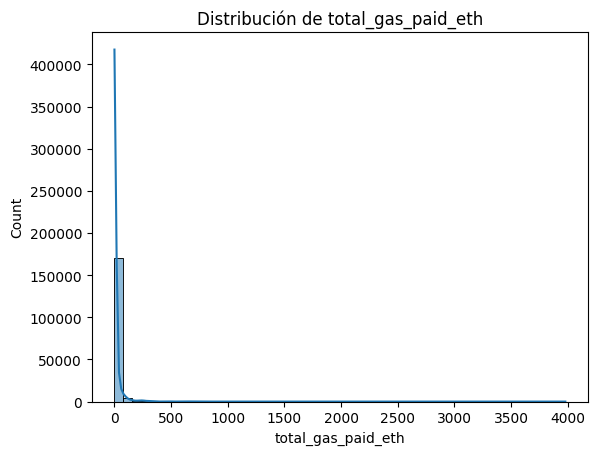

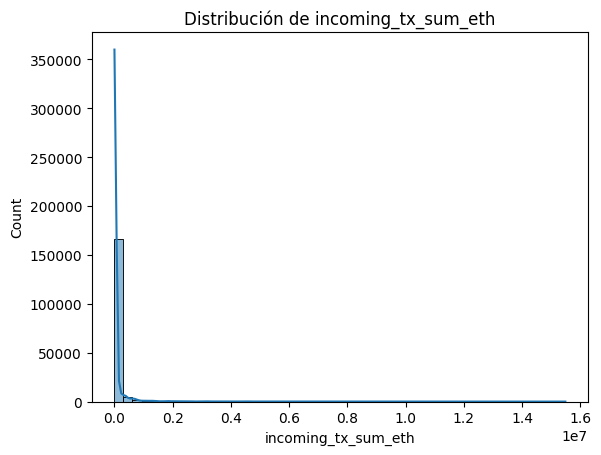

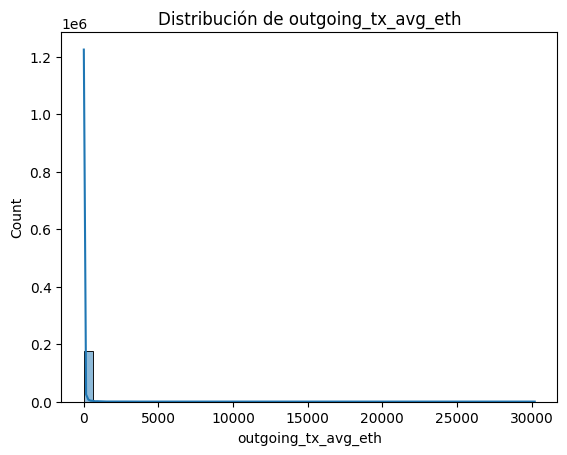

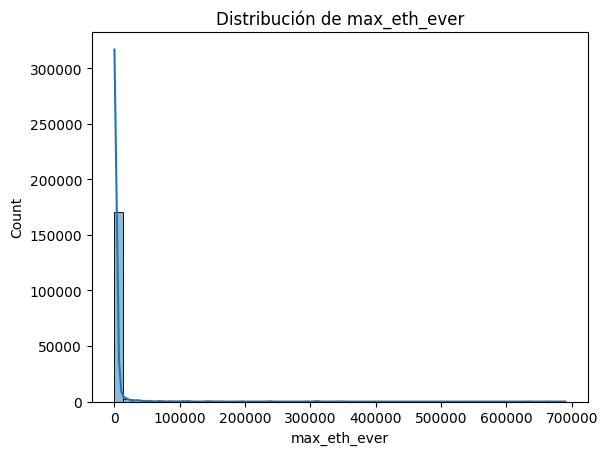

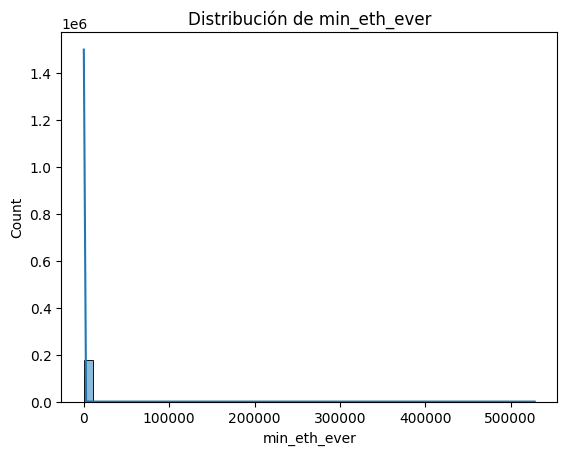

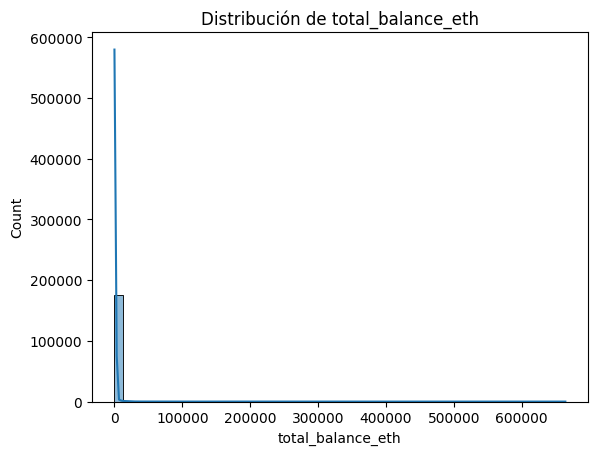

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['total_gas_paid_eth', 'incoming_tx_sum_eth', 'outgoing_tx_avg_eth',
            'max_eth_ever', 'min_eth_ever', 'total_balance_eth']:
    sns.histplot(datos_procesados[col], bins=50, kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()


Son variables que claramente se venifeciarian de una transformacion logaritmica con tal de parecer mas a una normal

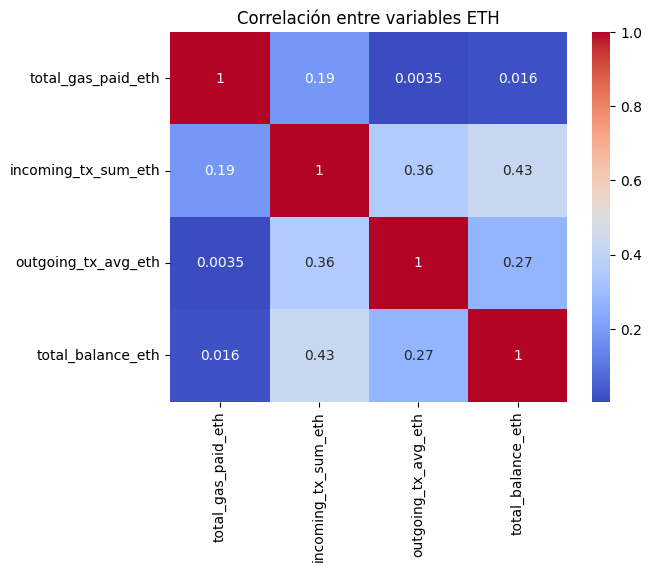

In [ ]:
correlation_matrix_eth = datos_procesados[['total_gas_paid_eth', 'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'total_balance_eth']].corr()
sns.heatmap(correlation_matrix_eth, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables ETH')
plt.show()

Si en una de esas queremos categorizar como

* Dormant (Inactiva):
Bajo saldo actual (total_balance_eth).
Bajos flujos de entrada y salida (incoming_tx_sum_eth y outgoing_tx_avg_eth).

* Active (Activa):
Altos valores en gas pagado (total_gas_paid_eth).
Flujos significativos de entrada o salida.

* High-Net-Worth (Alto patrimonio):
Alto saldo actual (total_balance_eth) o saldo máximo histórico (max_eth_ever)

Podriamos usar el siguente codigo

In [ ]:
# def classify_activity(row):
#     if row['total_balance_eth'] < 0.01 and row['incoming_tx_sum_eth'] < 0.01 and row['outgoing_tx_avg_eth'] < 0.01:
#         return 'Dormant'
#     elif row['total_gas_paid_eth'] > 0.05 or row['incoming_tx_sum_eth'] > 0.05 or row['outgoing_tx_avg_eth'] > 0.05:
#         return 'Active'
#     elif row['total_balance_eth'] > 1 or row['max_eth_ever'] > 5:
#         return 'High-Net-Worth'
#     else:
#         return 'Moderate'

# # Aplicar clasificación
# data['activity_class'] = data.apply(classify_activity, axis=1)

# # Contar las categorías
# print(data['activity_class'].value_counts())

# # Visualización
# sns.countplot(x='activity_class', data=data, order=['Dormant', 'Moderate', 'Active', 'High-Net-Worth'])
# plt.title('Clasificación de actividad de billeteras')
# plt.show()


## 1.3 Correlación y Relaciones entre Variables

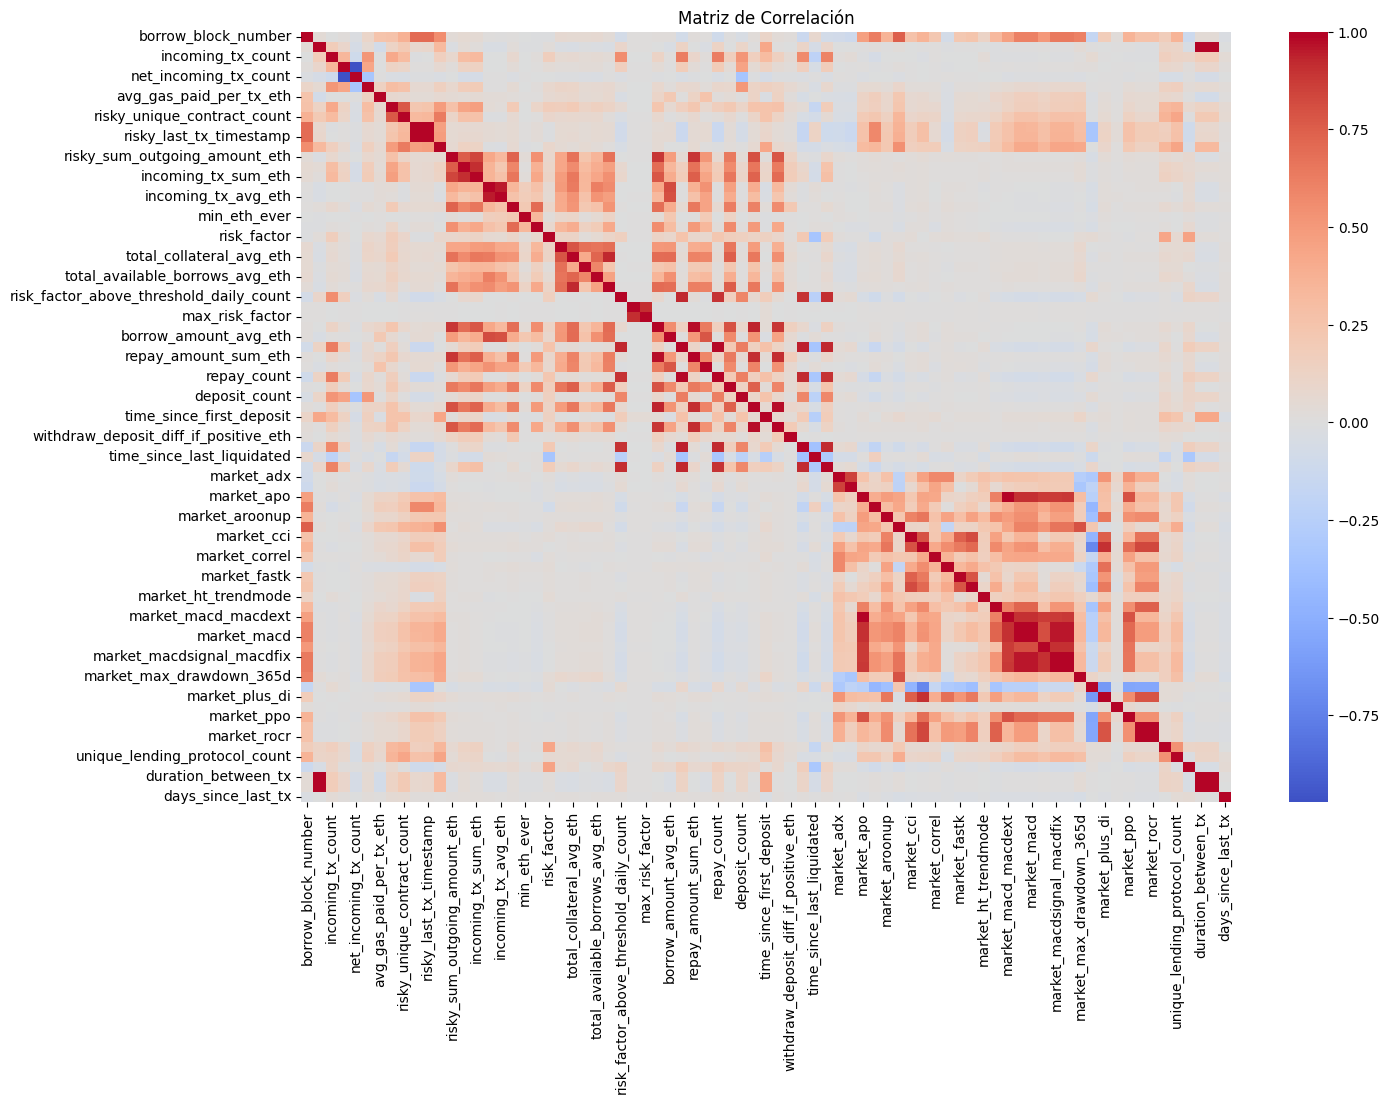


Correlaciones más altas con 'target':
target                                     1.000000
risk_factor                                0.449982
borrow_count                               0.176241
liquidation_count                          0.168014
repay_count                                0.166398
liquidation_amount_sum_eth                 0.131908
risk_factor_above_threshold_daily_count    0.114475
borrow_repay_diff_eth                      0.114161
unique_borrow_protocol_count               0.110392
incoming_tx_count                          0.110139
Name: target, dtype: float64

Correlaciones más bajas con 'target':
time_since_last_liquidated   -0.324033
borrow_block_number          -0.121135
risky_last_tx_timestamp      -0.096964
risky_first_tx_timestamp     -0.096689
market_aroonosc              -0.088169
market_atr                   -0.071187
market_macdsignal            -0.064144
market_macdsignal_macdfix    -0.064134
market_macd_macdfix          -0.060870
market_macd           

In [ ]:
# Selección de variables numéricas
num_vars = datos_procesados.select_dtypes(include=[np.number])

# Calcular matriz de correlación
correlation_matrix = num_vars.corr()

# Visualización de la matriz
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Imprimir las correlaciones más altas con 'target'
print("\nCorrelaciones más altas con 'target':")
print(correlation_matrix['target'].sort_values(ascending=False).head(10))
print("\nCorrelaciones más bajas con 'target':")
print(correlation_matrix['target'].sort_values(ascending=True).head(10))

In [ ]:
# Si queremos observar mejor los detalles de las correlackones podemos usar lo sigunte
df = pd.DataFrame(num_vars, index=num_vars.index.tolist(), columns=num_vars.columns.tolist())
corr_df = df.corr()
corr_df.style.background_gradient(cmap="coolwarm")


Correlaciones más altas con 'target':
target                                     1.000000
risk_factor                                0.449982
borrow_count                               0.176241
liquidation_count                          0.168014
repay_count                                0.166398
liquidation_amount_sum_eth                 0.131908
risk_factor_above_threshold_daily_count    0.114475
borrow_repay_diff_eth                      0.114161
unique_borrow_protocol_count               0.110392
incoming_tx_count                          0.110139
Name: target, dtype: float64

Correlaciones más bajas con 'target':
time_since_last_liquidated   -0.324033
borrow_block_number          -0.121135
risky_last_tx_timestamp      -0.096964
risky_first_tx_timestamp     -0.096689
market_aroonosc              -0.088169
market_atr                   -0.071187
market_macdsignal            -0.064144
market_macdsignal_macdfix    -0.064134
market_macd_macdfix          -0.060870
market_macd           

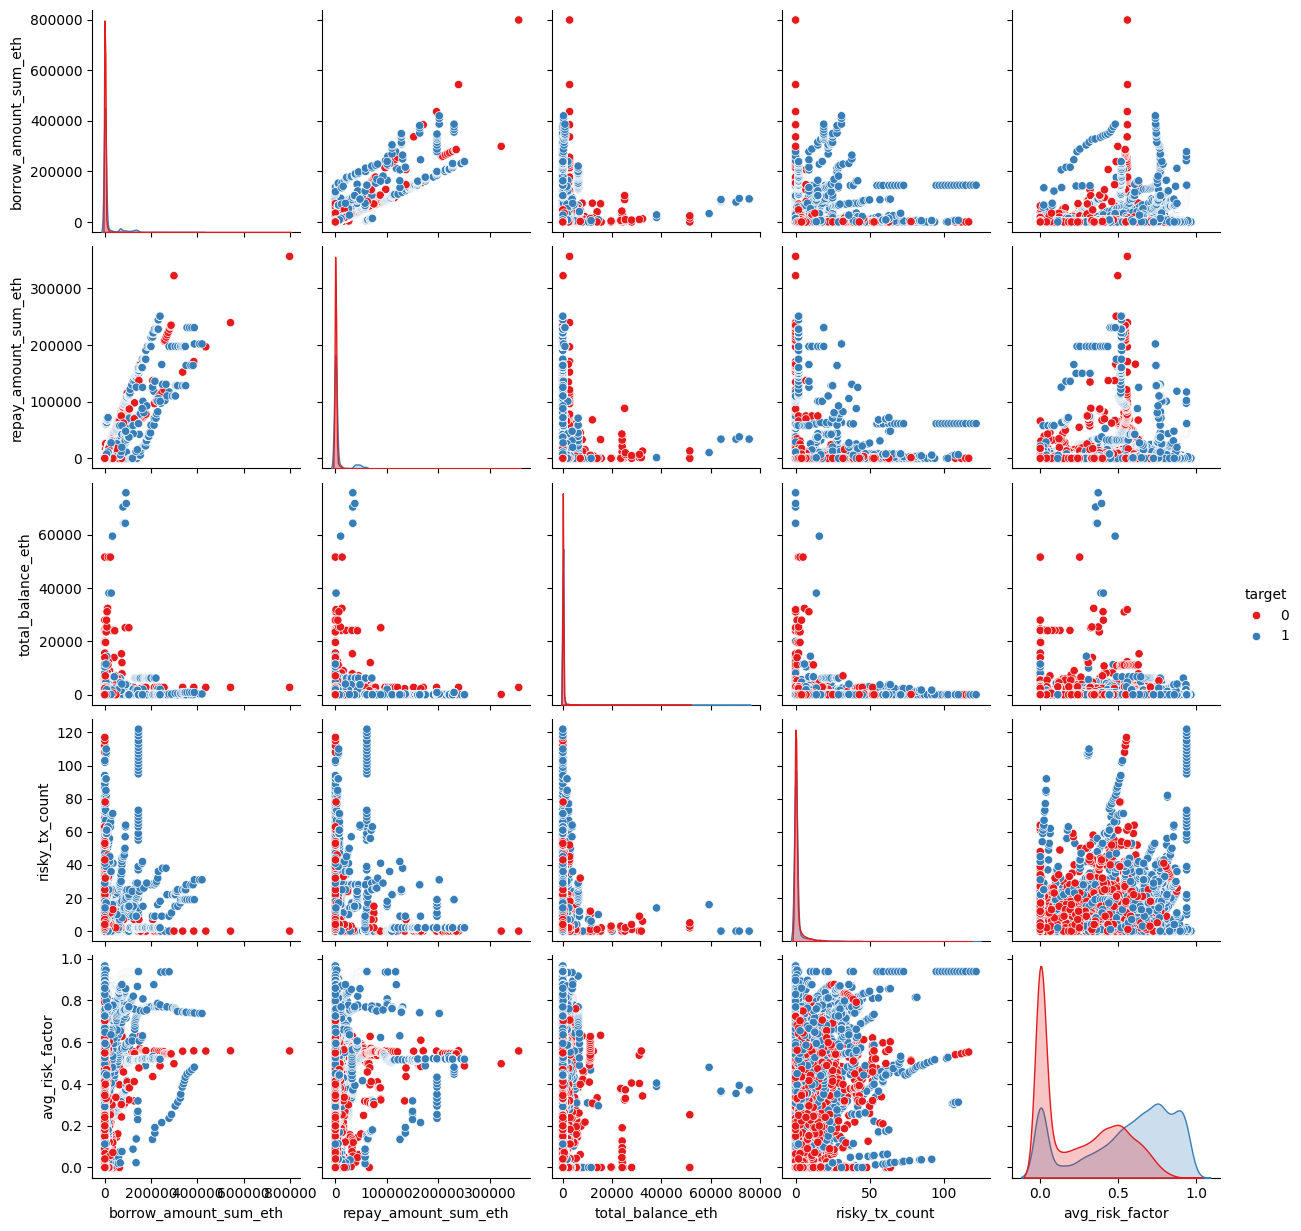

In [ ]:
# Selección de algunas variables para visulizar
scatter_vars = [
    'borrow_amount_sum_eth', 'repay_amount_sum_eth',
    'total_balance_eth', 'risky_tx_count', 'avg_risk_factor', 'target'
]
sns.pairplot(data[scatter_vars], hue='target', diag_kind='kde', palette='Set1')
plt.show()


Podemos ver de las matrices de correlacion que existen varias variables altamente correlacionadas que podríamos reducir.

Ademas, como era de esperarse la variable con mayor correlacion con el target son las relacionadas al factor de riesgo, como 'risk_factor'.

Por otro lado las relaciones entre las variables que elegimos graficar, exceptuando un par de relaciones lineales obvias como repay_amount con borrow_amount, son un poco mas complicadas al relacionar variables con un alto nivel de sesgo, por lo que aplicar transfomaciones tipo logaritmo con estas variables no seria una mala idea.

Un primer filtro que introduciremos sera la eliminacion de variables altamente correlacionadas. Manteniendo la variable mas relevante (con mayor correlación) respecto al target.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# 1. Identificar pares con alta correlación
high_corr_pairs = [
    (col1, col2, correlation_matrix.loc[col1, col2])
    for col1 in correlation_matrix.columns
    for col2 in correlation_matrix.columns
    if col1 != col2 and abs(correlation_matrix.loc[col1, col2]) > 0.85
]

# 2. Determinar variables a eliminar
variables_to_drop = set()
for col1, col2, corr in high_corr_pairs:
    relevance_col1 = abs(correlation_matrix.loc[col1, 'target']) if 'target' in correlation_matrix else 0
    relevance_col2 = abs(correlation_matrix.loc[col2, 'target']) if 'target' in correlation_matrix else 0
    if relevance_col1 >= relevance_col2:
        variables_to_drop.add(col2)
    else:
        variables_to_drop.add(col1)

# 3. Eliminar las variables seleccionadas
data_reduced = datos_procesados.drop(columns=variables_to_drop)
data_reduced = data_reduced.drop(columns=['wallet_address'], errors='ignore') # errors='ignore' to avoid error if already dropped

# 4.  Filtro de baja varianza
# --- Nuevo código ---
selector = VarianceThreshold(threshold=0.01)  # Treshold arbitrario

# Get the column names before applying fit_transform
original_columns = data_reduced.columns

# Apply fit_transform to get the transformed data and remaining feature names
data_reduced_array = selector.fit_transform(data_reduced)
remaining_features = original_columns[selector.get_support()]

# Create the reduced DataFrame using the correct feature names
data_reduced = pd.DataFrame(data_reduced_array, columns=remaining_features)

In [ ]:
reduccion = data.shape[1] - data_reduced.shape[1]
print(f"Se redujo el dataset en {reduccion} variables.")

Se redujo el dataset en 28 variables.


In [ ]:
data_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177184 entries, 0 to 177183
Data columns (total 50 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   borrow_block_number                    177184 non-null  float64
 1   incoming_tx_count                      177184 non-null  float64
 2   outgoing_tx_count                      177184 non-null  float64
 3   total_gas_paid_eth                     177184 non-null  float64
 4   risky_tx_count                         177184 non-null  float64
 5   risky_unique_contract_count            177184 non-null  float64
 6   risky_last_tx_timestamp                177184 non-null  float64
 7   risky_first_last_tx_timestamp_diff     177184 non-null  float64
 8   incoming_tx_sum_eth                    177184 non-null  float64
 9   outgoing_tx_avg_eth                    177184 non-null  float64
 10  max_eth_ever                           177184 non-null  

In [ ]:
data_reduced_cols = data_reduced.columns.tolist()

In [ ]:
data_reduced_cols

['borrow_block_number',
 'incoming_tx_count',
 'outgoing_tx_count',
 'total_gas_paid_eth',
 'risky_tx_count',
 'risky_unique_contract_count',
 'risky_last_tx_timestamp',
 'risky_first_last_tx_timestamp_diff',
 'incoming_tx_sum_eth',
 'outgoing_tx_avg_eth',
 'max_eth_ever',
 'min_eth_ever',
 'total_balance_eth',
 'risk_factor',
 'total_collateral_eth',
 'total_available_borrows_eth',
 'total_available_borrows_avg_eth',
 'avg_weighted_risk_factor',
 'max_risk_factor',
 'borrow_amount_avg_eth',
 'borrow_count',
 'repay_amount_avg_eth',
 'borrow_repay_diff_eth',
 'deposit_count',
 'deposit_amount_sum_eth',
 'time_since_first_deposit',
 'withdraw_deposit_diff_if_positive_eth',
 'time_since_last_liquidated',
 'market_adxr',
 'market_aroonosc',
 'market_aroonup',
 'market_atr',
 'market_cci',
 'market_cmo',
 'market_dx',
 'market_fastk',
 'market_fastd',
 'market_ht_trendmode',
 'market_linearreg_slope',
 'market_macdsignal',
 'market_max_drawdown_365d',
 'market_natr',
 'market_plus_dm',
 'm



```
data_reduced: ['borrow_block_number',
 'incoming_tx_count',
 'outgoing_tx_count',
 'total_gas_paid_eth',
 'risky_tx_count',
 'risky_unique_contract_count',
 'risky_last_tx_timestamp',
 'risky_first_last_tx_timestamp_diff',
 'incoming_tx_sum_eth',
 'outgoing_tx_avg_eth',
 'max_eth_ever',
 'min_eth_ever',
 'total_balance_eth',
 'risk_factor',
 'total_collateral_eth',
 'total_available_borrows_eth',
 'total_available_borrows_avg_eth',
 'avg_weighted_risk_factor',
 'max_risk_factor',
 'borrow_amount_avg_eth',
 'borrow_count',
 'repay_amount_avg_eth',
 'borrow_repay_diff_eth',
 'deposit_count',
 'deposit_amount_sum_eth',
 'time_since_first_deposit',
 'withdraw_deposit_diff_if_positive_eth',
 'time_since_last_liquidated',
 'market_adxr',
 'market_aroonosc',
 'market_aroonup',
 'market_atr',
 'market_cci',
 'market_cmo',
 'market_dx',
 'market_fastk',
 'market_fastd',
 'market_ht_trendmode',
 'market_linearreg_slope',
 'market_macdsignal',
 'market_max_drawdown_365d',
 'market_natr',
 'market_plus_dm',
 'market_ppo',
 'market_rocp',
 'unique_borrow_protocol_count',
 'unique_lending_protocol_count',
 'target',
 'days_since_borrow',
 'days_since_last_tx']
```



In [ ]:
def align_columns(df_to_align, list_reference):
    """
    Aligns the columns of a DataFrame (df_to_align) to match the columns of a reference DataFrame (df_reference).

    Args:
        df_to_align (pd.DataFrame): The DataFrame whose columns need to be aligned.
        df_reference (pd.DataFrame): The reference DataFrame with the desired columns.

    Returns:
        pd.DataFrame: The aligned DataFrame with columns matching the reference.
    """

    # 1. Get Column Names:
    to_align_cols = df_to_align.columns.tolist()

    # 2. Identify Columns to Drop:
    cols_to_drop = [col for col in to_align_cols if col not in list_reference]

    # 3. Drop the Identified Columns:
    data_reduced = df_to_align.drop(columns=cols_to_drop, errors='ignore') # errors='ignore' to avoid errors if a column is already dropped

    return data_reduced

In [ ]:
X_t2_reduced = align_columns(X_t2_procesados, data_reduced)

In [ ]:
# Obtener las columnas presentes en data_reduced
data_reduced_cols = data_reduced.columns.tolist()

# Obtener las columnas presentes en X_t2
X_t2_cols = X_t2.columns.tolist()

# Encontrar las columnas que están en X_t2 pero no en data_reduced
cols_to_drop = [col for col in X_t2_cols if col not in data_reduced_cols]

# Eliminar las columnas de X_t2
X_t2_reduced = X_t2.drop(columns=cols_to_drop)

# Verificar las dimensiones del DataFrame resultante
print(X_t2_reduced.shape)

In [ ]:
X_t2_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88592 entries, 177184 to 265775
Data columns (total 49 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   borrow_block_number                    88592 non-null  int64  
 1   incoming_tx_count                      88592 non-null  int64  
 2   outgoing_tx_count                      88592 non-null  int64  
 3   total_gas_paid_eth                     88592 non-null  float64
 4   risky_tx_count                         88592 non-null  int64  
 5   risky_unique_contract_count            88592 non-null  int64  
 6   risky_last_tx_timestamp                88592 non-null  int64  
 7   risky_first_last_tx_timestamp_diff     88592 non-null  int64  
 8   incoming_tx_sum_eth                    88592 non-null  float64
 9   outgoing_tx_avg_eth                    88592 non-null  float64
 10  max_eth_ever                           88592 non-null  float64
 

In [ ]:
# Excluir la columna 'target' de data_reduced para la comparación
data_reduced_cols_no_target = data_reduced.drop(columns=['target']).columns.tolist()

# Verificar que las columnas sean las mismas, sin importar el orden
assert set(X_t2_reduced.columns) == set(data_reduced_cols_no_target)

# 2. Preprocesamiento

PD: Varias prerpocesamientos ya estan en el EDA, pasarlos de ahi aqui (como tratamiendo outliers y filtro de correlacion)

## 1.1 Estandarización

In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

# Seleccionamos las variables numéricas
numeric_columns = data_reduced.select_dtypes(include=['float64', 'int64']).columns.drop(['target'])
scaler = StandardScaler()

# # Transformación logarítmica para variables sesgadas (es una opcion futura)
# skewed_columns = ['total_gas_paid_eth', 'incoming_tx_sum_eth']  # Ejemplo que vimos en el EDA
# for col in skewed_columns:
#     data[col] = PowerTransformer(method='yeo-johnson').fit_transform(data[[col]])

# Eliminar 'wallet_address' al ser simplemente ids (segun entendi jeje)
#data_treated.drop(columns=['wallet_address'], inplace=True)

## 1.2 Reducción de Dimensionalidad:

Consideramos que la reducción de dimensionalidad realizada filtrando columnas altamente relacionadas en el EDA es suficiente por ahora. Además, ya que la interpretabilidad del modelo es una parte importante del proyecto, aplicar técnicas de reducción de dimensionalidad más avanzadas (ej: PCA, T-SNE o U-MAP) dificultaría (por no decir imposibilitaría) la interpretación de los resultados en relación a las variables originales del modelo.

# 3. División del conjunto de datos
Implementen una técnica Hold-Out, separando el conjunto de datos en 70% para entrenamiento y 30% para testeo.

In [ ]:
from sklearn.model_selection import train_test_split

# Dividimos los datos en conjuntos de entrenamiento y validación
X = data_reduced.drop(columns=['target'])
y = data_reduced['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Verificación final
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de validación:", X_val.shape)


Tamaño del conjunto de entrenamiento: (124028, 49)
Tamaño del conjunto de validación: (53156, 49)


In [ ]:
# Select all numeric columns from X_train
numeric_columns = X_train.select_dtypes(include=['number']).columns

# Apply the outlier handling to all numeric columns
X_train_treated = handle_outliers_with_percentiles(X_train, numeric_columns)
X_val_treated = handle_outliers_with_percentiles(X_val, numeric_columns)

In [ ]:
# Select all numeric columns from X_train
numeric_columns = X_t2_reduced.select_dtypes(include=['number']).columns

# Apply the outlier handling to all numeric columns
X_t2_treated = handle_outliers_with_percentiles(X_t2_reduced, numeric_columns)

In [ ]:
# Aplicar el scaler
X_train_treated[numeric_columns] = scaler.fit_transform(X_train_treated[numeric_columns])
X_val_treated[numeric_columns] = scaler.transform(X_val_treated[numeric_columns])

In [ ]:
X_t2_treated[numeric_columns] = scaler.transform(X_t2_treated[numeric_columns])

In [ ]:
X_t2_treated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88592 entries, 177184 to 265775
Data columns (total 49 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   borrow_block_number                    88592 non-null  float64
 1   incoming_tx_count                      88592 non-null  float64
 2   outgoing_tx_count                      88592 non-null  float64
 3   total_gas_paid_eth                     88592 non-null  float64
 4   risky_tx_count                         88592 non-null  float64
 5   risky_unique_contract_count            88592 non-null  float64
 6   risky_last_tx_timestamp                88592 non-null  float64
 7   risky_first_last_tx_timestamp_diff     88592 non-null  float64
 8   incoming_tx_sum_eth                    88592 non-null  float64
 9   outgoing_tx_avg_eth                    88592 non-null  float64
 10  max_eth_ever                           88592 non-null  float64
 

# 4. Creación de un modelo baseline

Elegimoss la regresión logística al ser un modelo sencillo, interpretable y muy adecuado como baseline para problemas de clasificación binaria .

La regresion de abajo se ejecuto usando los datos tratados de la primera y segunda entrega.

Reporte de clasificación:
              precision    recall  f1-score   support

   No Moroso       0.77      0.85      0.81     31286
      Moroso       0.75      0.63      0.69     21870

    accuracy                           0.76     53156
   macro avg       0.76      0.74      0.75     53156
weighted avg       0.76      0.76      0.76     53156

AUC-ROC: 0.5000


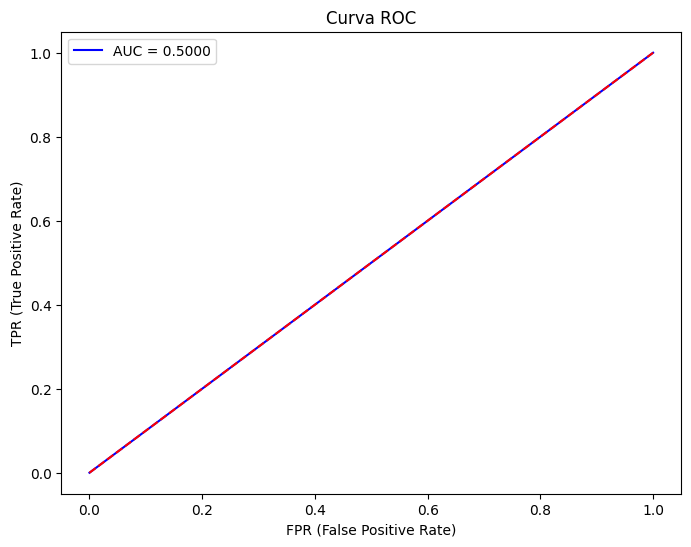

Coeficientes del modelo:
                                  Feature  Coefficient
13                            risk_factor     0.799784
18                        max_risk_factor     0.461901
17               avg_weighted_risk_factor     0.355136
14                   total_collateral_eth     0.331852
19                  borrow_amount_avg_eth     0.317515
46          unique_lending_protocol_count     0.208966
40               market_max_drawdown_365d     0.188346
23                          deposit_count     0.184184
48                     days_since_last_tx     0.154757
39                      market_macdsignal     0.149641
29                        market_aroonosc     0.147519
9                     outgoing_tx_avg_eth     0.132937
42                         market_plus_dm     0.130666
20                           borrow_count     0.120846
4                          risky_tx_count     0.118761
2                       outgoing_tx_count     0.098136
8                     incoming_tx_sum_et

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

# 1. Inicializamos el modelo
logistic_model = LogisticRegression(random_state=42, max_iter=500)

# 2. Entrenamos el modelo con los datos de entrenamiento
logistic_model.fit(X_train_treated, y_train)

# 3. Predicción en el conjunto de validación
y_pred = logistic_model.predict(X_val_treated)
y_pred_proba = logistic_model.predict_proba(X_val)[:, 1]

# 4. Evaluación con classification_report
print("Reporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso']))

# 5. Cálculo del AUC-ROC
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"AUC-ROC: {roc_auc:.4f}")

# 6. Gráfico de la curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Curva ROC')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.legend()
plt.show()

# 7. Análisis de los coeficientes (opcional)
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Coeficientes del modelo:")
print(coefficients)


# Desarrollo de 3 modelos de Machine Learning diferentes al baseline

Usando los datos sin tratamiento de la primera entega

Resultados para Random Forest:
              precision    recall  f1-score   support

   No Moroso       0.87      0.95      0.91      4343
      Moroso       0.95      0.87      0.91      4517

    accuracy                           0.91      8860
   macro avg       0.91      0.91      0.91      8860
weighted avg       0.91      0.91      0.91      8860

AUC-ROC: 0.9686
Resultados para SVM:
              precision    recall  f1-score   support

   No Moroso       0.77      0.89      0.82      4343
      Moroso       0.87      0.74      0.80      4517

    accuracy                           0.82      8860
   macro avg       0.82      0.82      0.81      8860
weighted avg       0.82      0.82      0.81      8860

AUC-ROC: 0.8847


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [02:57:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Resultados para XGBoost:
              precision    recall  f1-score   support

   No Moroso       0.86      0.92      0.89      4343
      Moroso       0.92      0.86      0.89      4517

    accuracy                           0.89      8860
   macro avg       0.89      0.89      0.89      8860
weighted avg       0.89      0.89      0.89      8860

AUC-ROC: 0.9559


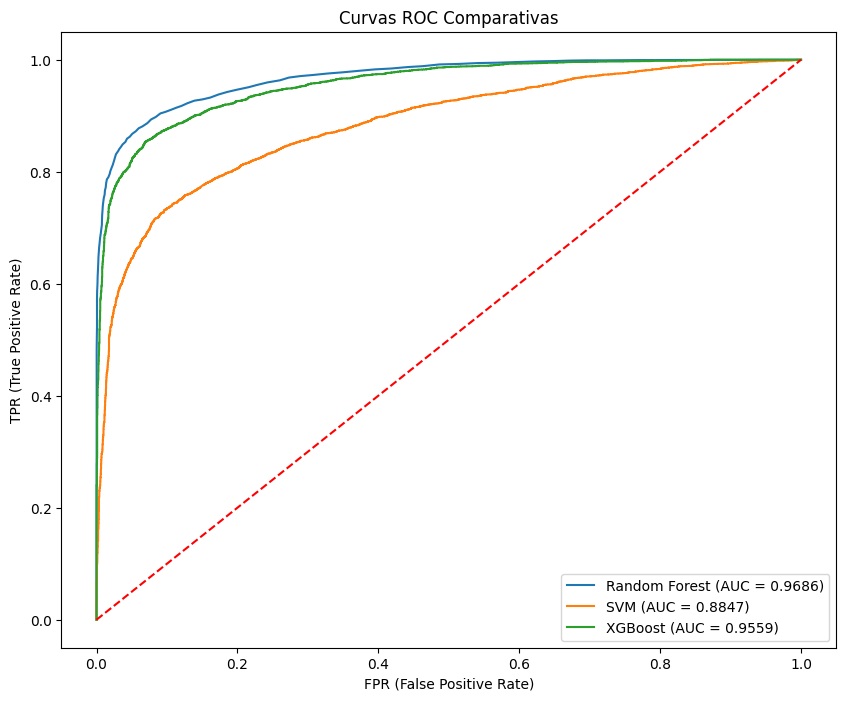


Comparación de AUC-ROC entre modelos:
                AUC-ROC
Random Forest  0.968644
SVM            0.884740
XGBoost        0.955910


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Diccionario para almacenar los resultados
results = {}

# Función para entrenar y evaluar un modelo
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val):
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    else:  # SVM con kernel no lineal no tiene predict_proba
        y_pred_proba = model.decision_function(X_val)

    # Métricas de clasificación
    report = classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso'], output_dict=True)
    auc_roc = roc_auc_score(y_val, y_pred_proba)

    # Guardar resultados
    results[model_name] = {
        "classification_report": classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso']),
        "AUC-ROC": auc_roc
    }

    # Imprimir métricas
    print(f"Resultados para {model_name}:")
    print(results[model_name]["classification_report"])
    print(f"AUC-ROC: {auc_roc:.4f}")

    # Graficar curva ROC
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.4f})')

# Crear instancias de los modelos
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Evaluar cada modelo
plt.figure(figsize=(10, 8))
for model_name, model in models.items():
    train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val)

# Configurar el gráfico de la curva ROC
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Curvas ROC Comparativas')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.legend()
plt.show()

# Comparar métricas
comparison_table = pd.DataFrame({
    model_name: {
        "AUC-ROC": results[model_name]["AUC-ROC"]
    }
    for model_name in models
}).T
print("\nComparación de AUC-ROC entre modelos:")
print(comparison_table)

Usando los datos con tratamiento de la primera y segunda entrega

Resultados para Random Forest:
              precision    recall  f1-score   support

   No Moroso       0.86      0.96      0.91     31286
      Moroso       0.93      0.78      0.85     21870

    accuracy                           0.89     53156
   macro avg       0.90      0.87      0.88     53156
weighted avg       0.89      0.89      0.89     53156

AUC-ROC: 0.9498


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:53:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Resultados para XGBoost:
              precision    recall  f1-score   support

   No Moroso       0.84      0.93      0.88     31286
      Moroso       0.88      0.74      0.81     21870

    accuracy                           0.85     53156
   macro avg       0.86      0.84      0.84     53156
weighted avg       0.86      0.85      0.85     53156

AUC-ROC: 0.9230


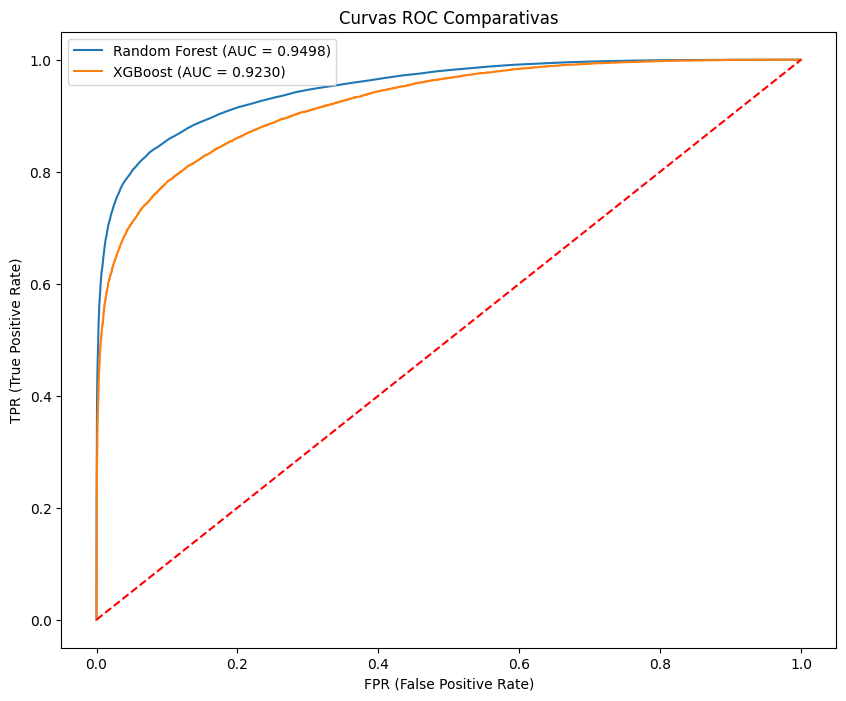


Comparación de AUC-ROC entre modelos:
                AUC-ROC
Random Forest  0.949811
XGBoost        0.922971


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Diccionario para almacenar los resultados
results = {}

# Función para entrenar y evaluar un modelo
def train_and_evaluate_model(model, model_name, X_train_treated, y_train, X_val_treated, y_val):
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    else:  # SVM con kernel no lineal no tiene predict_proba
        y_pred_proba = model.decision_function(X_val)

    # Métricas de clasificación
    report = classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso'], output_dict=True)
    auc_roc = roc_auc_score(y_val, y_pred_proba)

    # Guardar resultados
    results[model_name] = {
        "classification_report": classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso']),
        "AUC-ROC": auc_roc
    }

    # Imprimir métricas
    print(f"Resultados para {model_name}:")
    print(results[model_name]["classification_report"])
    print(f"AUC-ROC: {auc_roc:.4f}")

    # Graficar curva ROC
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.4f})')

# Crear instancias de los modelos
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
#    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Evaluar cada modelo
plt.figure(figsize=(10, 8))
for model_name, model in models.items():
    train_and_evaluate_model(model, model_name, X_train_treated, y_train, X_val_treated, y_val)

# Configurar el gráfico de la curva ROC
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Curvas ROC Comparativas')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.legend()
plt.show()

# Comparar métricas
comparison_table = pd.DataFrame({
    model_name: {
        "AUC-ROC": results[model_name]["AUC-ROC"]
    }
    for model_name in models
}).T
print("\nComparación de AUC-ROC entre modelos:")
print(comparison_table)

## Optimizacion

## intento de que xgb sea el best


Resultados para Random Forest:
AUC-ROC: 0.9514
AUC Precision-Recall: 0.9439


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:53:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Resultados para XGBoost:
AUC-ROC: 0.9224
AUC Precision-Recall: 0.9123


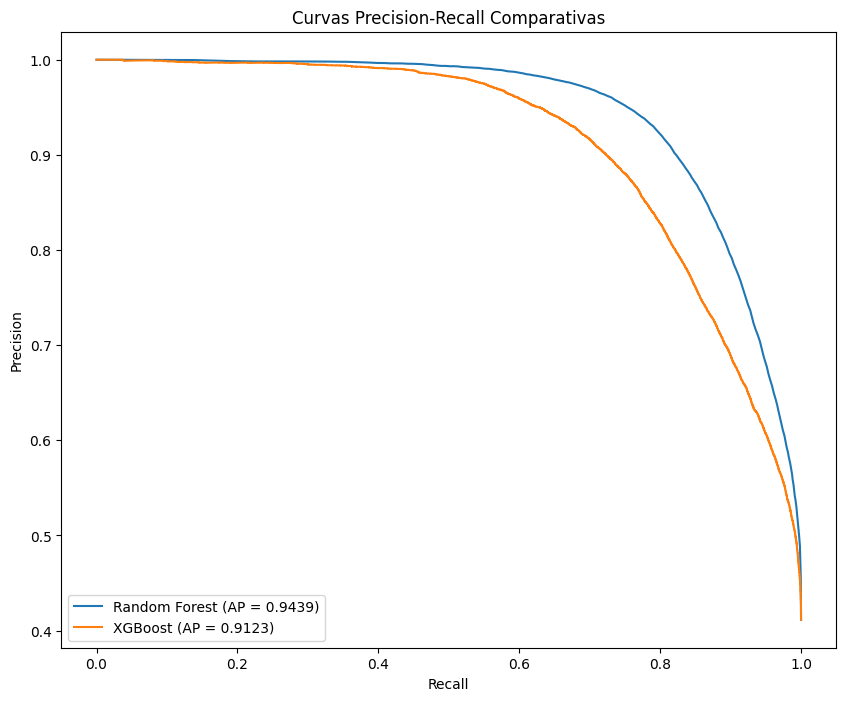


Comparación de métricas entre modelos:
                AUC-ROC  AUC Precision-Recall
Random Forest  0.951415              0.943918
XGBoost        0.922426              0.912314


In [ ]:
# nuevo con metrica
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Diccionario para almacenar los resultados
results = {}

# Función para entrenar y evaluar un modelo
def train_and_evaluate_model(model, model_name, X_train_treated, y_train, X_val_treated, y_val):
    # Entrenamiento
    model.fit(X_train_treated, y_train)

    # Predicciones
    y_pred = model.predict(X_val_treated)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_val_treated)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_val_treated)

    # Métricas
    auc_roc = roc_auc_score(y_val, y_pred_proba)
    avg_precision = average_precision_score(y_val, y_pred_proba)
    results[model_name] = {
        "AUC-ROC": auc_roc,
        "AUC Precision-Recall": avg_precision
    }

    # Reporte
    print(f"\nResultados para {model_name}:")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"AUC Precision-Recall: {avg_precision:.4f}")

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
    plt.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.4f})')

# Crear instancias de los modelos
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', max_depth=6)
}

# Evaluar cada modelo
plt.figure(figsize=(10, 8))
for model_name, model in models.items():
    train_and_evaluate_model(model, model_name, X_train_treated, y_train, X_val_treated, y_val)

# Configuración de la gráfica Precision-Recall
plt.title('Curvas Precision-Recall Comparativas')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Comparar métricas
comparison_table = pd.DataFrame(results).T
print("\nComparación de métricas entre modelos:")
print(comparison_table)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 5.6 MB/s eta 0:00:00


Utilizaremos Optuna para la búsqueda de los mejores hiperparámetros

In [ ]:
import warnings
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

warnings.filterwarnings('ignore', category=UserWarning)

# Función objetivo para Optuna
def objective(trial):
    # Espacio de búsqueda de hiperparámetros
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    # Crear y entrenar el modelo
    model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    **params
    )

    model.fit(X_train_treated, y_train)

    # Predicciones en el conjunto de validación
    y_pred_proba = model.predict_proba(X_val_treated)[:, 1]

    # Métrica de evaluación
    return average_precision_score(y_val, y_pred_proba)  # AUC Precision-Recall

# Crear un estudio de Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC Precision-Recall:", study.best_value)

# Entrenar el modelo final con los mejores parámetros
best_params = study.best_params
final_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    **best_params
)
final_model.fit(X_train_treated, y_train)

# Evaluar el modelo final
y_pred_proba = final_model.predict_proba(X_val_treated)[:, 1]
final_auc_pr = average_precision_score(y_val, y_pred_proba)
print(f"AUC Precision-Recall del modelo final: {final_auc_pr:.4f}")

[I 2024-12-05 23:46:29,264] A new study created in memory with name: no-name-5a3e6d0a-f5b7-4bc3-a4f1-6721d5bacac7
[I 2024-12-05 23:46:37,550] Trial 0 finished with value: 0.9043140623090473 and parameters: {'max_depth': 5, 'learning_rate': 0.2880632309839574, 'n_estimators': 142, 'subsample': 0.5799468677091785, 'colsample_bytree': 0.9088093133679568, 'gamma': 0.45669634094349654, 'min_child_weight': 2, 'reg_alpha': 0.9345905123615285, 'reg_lambda': 0.626775167440553}. Best is trial 0 with value: 0.9043140623090473.
[I 2024-12-05 23:46:49,545] Trial 1 finished with value: 0.9071545266365804 and parameters: {'max_depth': 10, 'learning_rate': 0.04995387987882246, 'n_estimators': 95, 'subsample': 0.7719477137027679, 'colsample_bytree': 0.6573856996704677, 'gamma': 2.816014674775147, 'min_child_weight': 9, 'reg_alpha': 0.5830944036070274, 'reg_lambda': 0.3345394030406885}. Best is trial 1 with value: 0.9071545266365804.
[I 2024-12-05 23:46:53,762] Trial 2 finished with value: 0.86869022548

Mejores hiperparámetros: {'max_depth': 9, 'learning_rate': 0.1524297059996229, 'n_estimators': 277, 'subsample': 0.7752805572101599, 'colsample_bytree': 0.6348434516530685, 'gamma': 1.2119889562151533, 'min_child_weight': 2, 'reg_alpha': 0.9457121842101034, 'reg_lambda': 0.19549380594565136}
Mejor AUC Precision-Recall: 0.9412217203514923
AUC Precision-Recall del modelo final: 0.9412


Tenemos un AUC mejor que lo anterior, pero seguimos sin ganarle al rf, so...
probemos con stacking (que no sé si debamos usarlo la vdd jej) y tambien con 100 trials y más hiperparámetros

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# Crear los modelos base
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')

# Crear el modelo de ensamblado
stacking_model = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    final_estimator=LogisticRegression(),  # Se puede cambiar esto según el caso
    cv=5  # Validación cruzada
)

# Entrenar el modelo de stacking
stacking_model.fit(X_train_treated, y_train)

# Evaluar el modelo
y_pred_proba = stacking_model.predict_proba(X_val_treated)[:, 1]
stacking_auc_pr = average_precision_score(y_val, y_pred_proba)
print(f"AUC Precision-Recall del modelo de Stacking: {stacking_auc_pr:.4f}")

AUC Precision-Recall del modelo de Stacking: 0.9469


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# Función objetivo para Optuna
def objective(trial):
    # Espacio de búsqueda de hiperparámetros
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),  # Ampliado
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),  # Ampliado
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),  # Ampliado
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),  # Para desbalance
        'tree_method': 'hist'
    }

    # Crear y entrenar el modelo
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        **params
    )
    model.fit(X_train_treated, y_train)

    # Predicciones en el conjunto de validación
    y_pred_proba = model.predict_proba(X_val_treated)[:, 1]

    # Métrica de evaluación
    return average_precision_score(y_val, y_pred_proba)  # AUC Precision-Recall

# Crear un estudio de Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)  # Aumentamos los trials

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros:", study.best_params)
print("Mejor AUC Precision-Recall:", study.best_value)

# Entrenar el modelo final con los mejores parámetros
best_params = study.best_params
final_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    **best_params
)
final_model.fit(X_train_treated, y_train)

# Evaluar el modelo final
y_pred_proba = final_model.predict_proba(X_val_treated)[:, 1]
final_auc_pr = average_precision_score(y_val, y_pred_proba)
print(f"AUC Precision-Recall del modelo final: {final_auc_pr:.4f}")


[I 2024-12-06 00:46:17,360] A new study created in memory with name: no-name-bb745948-1959-444c-9155-f84b89e19726
[I 2024-12-06 00:48:28,473] Trial 0 finished with value: 0.9359925530518339 and parameters: {'max_depth': 15, 'learning_rate': 0.015138863947766453, 'n_estimators': 390, 'subsample': 0.6074420931386391, 'colsample_bytree': 0.8403834860947819, 'gamma': 2.8277877407110874, 'min_child_weight': 4, 'reg_alpha': 0.09611744773101116, 'reg_lambda': 0.7723540583876857, 'scale_pos_weight': 3.9078755043169924}. Best is trial 0 with value: 0.9359925530518339.
[I 2024-12-06 00:48:44,825] Trial 1 finished with value: 0.9356225630252364 and parameters: {'max_depth': 10, 'learning_rate': 0.19160202791674782, 'n_estimators': 144, 'subsample': 0.6650765677561763, 'colsample_bytree': 0.5152905178277032, 'gamma': 0.295286229646472, 'min_child_weight': 4, 'reg_alpha': 0.7797182428091375, 'reg_lambda': 0.17857553195903786, 'scale_pos_weight': 6.640314461610427}. Best is trial 0 with value: 0.935

Mejores hiperparámetros: {'max_depth': 14, 'learning_rate': 0.1352206839636242, 'n_estimators': 388, 'subsample': 0.685587017897287, 'colsample_bytree': 0.9184435533046019, 'gamma': 0.043744922398397626, 'min_child_weight': 1, 'reg_alpha': 0.815664399566439, 'reg_lambda': 0.9366788600511666, 'scale_pos_weight': 2.316042039232425}
Mejor AUC Precision-Recall: 0.9540046209258828
AUC Precision-Recall del modelo final: 0.9540


In [ ]:
best_params

{'max_depth': 14,
 'learning_rate': 0.1352206839636242,
 'n_estimators': 388,
 'subsample': 0.685587017897287,
 'colsample_bytree': 0.9184435533046019,
 'gamma': 0.043744922398397626,
 'min_child_weight': 1,
 'reg_alpha': 0.815664399566439,
 'reg_lambda': 0.9366788600511666,
 'scale_pos_weight': 2.316042039232425}

best param:

`{'max_depth': 14,
'learning_rate': 0.1352206839636242
'n_estimators': 388,
'subsample': 0.685587017897287,
'colsample_bytree': 0.9184435533046019,
'gamma': 0.043744922398397626,
'min_child_weight': 1,
'reg_alpha': 0.815664399566439,
'reg_lambda': 0.9366788600511666,
'scale_pos_weight': 2.316042039232425}`

In [ ]:
import tensorflow as tf
print("¿GPU disponible?", tf.config.list_physical_devices('GPU'))

¿GPU disponible? []


### Entrenamiento del mejor modelo para siguentes partes:



In [ ]:
best_params = {'max_depth': 14,
 'learning_rate': 0.1352206839636242,
 'n_estimators': 388,
 'subsample': 0.685587017897287,
 'colsample_bytree': 0.9184435533046019,
 'gamma': 0.043744922398397626,
 'min_child_weight': 1,
 'reg_alpha': 0.815664399566439,
 'reg_lambda': 0.9366788600511666,
 'scale_pos_weight': 2.316042039232425}

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

#
# Entrenar el modelo final con los mejores parámetros
final_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    **best_params
)
final_model.fit(X_train_treated, y_train)

# Evaluar el modelo final
y_pred_proba = final_model.predict_proba(X_val_treated)[:, 1]
final_auc_pr = average_precision_score(y_val, y_pred_proba)
print(f"AUC Precision-Recall del modelo final: {final_auc_pr:.4f}")

AUC Precision-Recall del modelo final: 0.9540


In [ ]:
import xgboost as xgb
# Guardar el modelo entrenado
final_model.save_model(path + 'final_model.xgb')

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:50:11] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [ ]:
import xgboost as xgb
# Cargar el modelo
loaded_model = xgb.XGBClassifier()  # o xgb.XGBRegressor(), dependiendo del tipo de modelo
loaded_model.load_model(path + 'final_model.xgb')

## 5.1 Inferencia

In [ ]:
from sklearn.metrics import classification_report

# Assuming you have already executed the following:
rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_t2_treated)

# Generate the classification report
report = classification_report(y_t1, y_pred, target_names=['No Moroso', 'Moroso'])

# Print the report
print(report)

              precision    recall  f1-score   support

   No Moroso       0.80      0.68      0.74     82645
      Moroso       0.58      0.72      0.65     50243

    accuracy                           0.70    132888
   macro avg       0.69      0.70      0.69    132888
weighted avg       0.72      0.70      0.70    132888



In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# y_true: valores reales
# y_scores: probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_t1, y_pred)
auc_pr = auc(recall, precision)

print("AUC-PR:", auc_pr)

AUC-PR: 0.7049771966804947


In [ ]:
from sklearn.metrics import classification_report

# Assuming you have already executed the following:
rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_val)

# Generate the classification report
report = classification_report(y_val, y_pred, target_names=['No Moroso', 'Moroso'])

# Print the report
print(report)

              precision    recall  f1-score   support

   No Moroso       0.86      0.94      0.90      6492
      Moroso       0.94      0.86      0.90      6797

    accuracy                           0.90     13289
   macro avg       0.90      0.90      0.90     13289
weighted avg       0.90      0.90      0.90     13289



In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# y_true: valores reales
# y_scores: probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_val, y_pred)
auc_pr = auc(recall, precision)

print("AUC-PR:", auc_pr)

AUC-PR: 0.9344179328379195


Aqui

In [ ]:
# Asegurarse  de que X_t2_prepared esté completamente preprocesado antes de usarlo.

# # Extraer el modelo Random Forest del diccionario
# rf_model = models["Random Forest"]

# new: ganó xgb (final_model)

# Usar la función generateFiles para crear el archivo de predicciones
from zipfile import ZipFile
import os

def generateFiles(predict_data, clf_pipe):
    """Genera los archivos a subir en CodaLab.

    Input
    ---------------
    predict_data: Dataframe con los datos de entrada a predecir
    clf_pipe: pipeline o modelo del clf

    Ouput
    ---------------
    archivo de txt y zip con predicciones
    """
    # Obtener probabilidades
    y_pred_clf = clf_pipe.predict_proba(predict_data)[:, 1]

    # Guardar en un archivo txt
    with open('./predictions.txt', 'w') as f:
        for item in y_pred_clf:
            f.write("%s\n" % item)

    # Comprimir en un archivo zip
    with ZipFile('predictions.zip', 'w') as zipObj:
        zipObj.write('predictions.txt')

    # Eliminar archivo temporal txt
    os.remove('predictions.txt')

# Generar el archivo de predicciones usando el modelo Random Forest
generateFiles(X_t2_treated, final_model)

print("Archivo de predicciones generado exitosamente: predictions.zip")

Archivo de predicciones generado exitosamente: predictions.zip


# 6. Interpretabilidad

## Feature Importance nativo

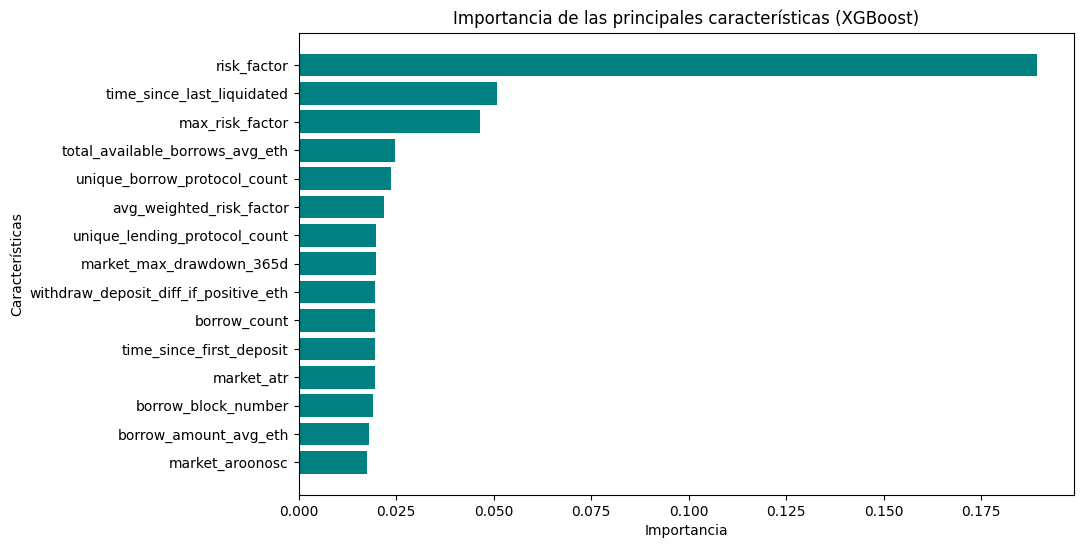


Tabla de Importancia de Características (XGBoost):


,Feature,Importance
13,risk_factor,0.189253
27,time_since_last_liquidated,0.050799
18,max_risk_factor,0.046516
16,total_available_borrows_avg_eth,0.024793
45,unique_borrow_protocol_count,0.023637
17,avg_weighted_risk_factor,0.021840
46,unique_lending_protocol_count,0.019883
40,market_max_drawdown_365d,0.019737
26,withdraw_deposit_diff_if_positive_eth,0.019685
20,borrow_count,0.019654


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Importancias de las características para el modelo XGBoost (final_model or loaded_model)
feature_importances = loaded_model.feature_importances_
features = X_train.columns

# DataFrame para ordenar y visualizar
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Visualizar las principales características
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], color='teal')
plt.gca().invert_yaxis()
plt.title('Importancia de las principales características (XGBoost)')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

# Imprimir tabla de importancias
print("\nTabla de Importancia de Características (XGBoost):")
display(importance_df.head(15))

In [ ]:
X_val_treated.shape, X_t2_treated.shape

((53156, 49), (88592, 49))

## Interpretación con SHAP

Calculemos los shap values para las variables mas importantes del modelo XGBoost

In [ ]:
# Seleccionar las 15 principales características
top_features = importance_df['Feature'][:15].tolist()

# Crear un DataFrame con las mismas columnas que el modelo original
X_val_fixed = X_val.copy()

# Mantener solo las columnas del modelo; rellenar las ausentes con ceros
X_val_fixed = X_val_fixed.reindex(columns=features, fill_value=0)

# Mantener solo las 15 variables más importantes para el análisis SHAP
X_val_top = X_val_fixed[top_features]

NameError: name 'importance_df' is not defined

In [ ]:
import random

# Crear el explainer
explainer = shap.TreeExplainer(loaded_model)

sample_size = 1000  # Or any other desired size
X_val_sample = X_val_fixed.sample(n=sample_size, random_state=42)  # For reproducibility

shap_values = explainer.shap_values(X_val_sample)

In [ ]:
# Filtrar SHAP values solo para las 15 características
shap_values_top = shap_values[:, :len(top_features)]

# Gráfico resumen para las 15 variables principales
shap.summary_plot(shap_values_top, X_val_top)

In [ ]:
# Gráfico resumen de SHAP values
shap.summary_plot(shap_values, X_val_top, plot_type="bar")

In [ ]:
# Seleccionar una fila específica del conjunto de validación
row_idx = 0  # Cambiar según el índice de interés

# Explicación específica para esa fila
shap.force_plot(
    explainer.expected_value,
    shap_values[row_idx, :],
    X_val_top.iloc[row_idx, :],
    matplotlib=True
)

# Reentrenamineto incremental sacado de [link](https://stackoverflow.com/questions/38079853/how-can-i-implement-incremental-training-for-xgboost)

In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve, auc
from joblib import dump, load

# Función para entrenar y reentrenar el modelo
class IncrementalXGBoost:
    def __init__(self, params=None):
        """
        Inicializa el modelo XGBoost con parámetros específicos.
        """
        if params is None:
            params = {
                "objective": "binary:logistic",
                "max_depth": 6,
                "learning_rate": 0.1,
                "n_estimators": 100,
            }
        self.params = params
        self.model = None

    def train_initial_model(self, X_train, y_train):
        """
        Entrena el modelo inicial con todos los datos.
        """
        dtrain = xgb.DMatrix(X_train, label=y_train)
        self.model = xgb.train(self.params, dtrain, num_boost_round=self.params["n_estimators"])
        print("Modelo inicial entrenado.")

    def update_model(self, X_new, y_new):
        """
        Actualiza el modelo con nuevos datos utilizando incremental boosting.
        """
        if self.model is None:
            raise ValueError("El modelo no ha sido inicializado. Entrena primero el modelo inicial.")

        dnew = xgb.DMatrix(X_new, label=y_new)
        self.model = xgb.train(self.params, dnew, xgb_model=self.model)
        print("Modelo actualizado con nuevos datos.")

    def predict(self, X):
        """
        Realiza predicciones con el modelo actual.
        """
        dtest = xgb.DMatrix(X)
        return self.model.predict(dtest)

    def evaluate_model(self, X, y_true):
        """
        Evalúa el modelo actual con datos de prueba.
        """
        y_pred = self.predict(X)
        y_pred_class = np.where(y_pred > 0.5, 1, 0)  # Para clasificación binaria
        accuracy = accuracy_score(y_true, y_pred_class)
        print(f"Precisión del modelo: {accuracy:.4f}")
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auc_pr = auc(recall, precision)
        print("AUC-PR:", auc_pr)
        return accuracy

    def save_model(self, filepath):
        """
        Guarda el modelo en disco.
        """
        self.model.save_model(filepath)
        print(f"Modelo guardado en {filepath}.")

    def load_model(self, filepath):
        """
        Carga el modelo desde disco.
        """
        self.model = xgb.Booster()
        self.model.load_model(filepath)
        print(f"Modelo cargado desde {filepath}.")

# Uso usando satos simples
if __name__ == "__main__":
    # Datos iniciales
    X_train = np.random.rand(100, 10)  # Datos dummy para probar
    y_train = np.random.randint(0, 2, 100)

    # Nuevos datos
    X_new = np.random.rand(20, 10)  # Datos nuevos
    y_new = np.random.randint(0, 2, 20)  # Etiquetas nuevas

    # Inicializar y entrenar el modelo
    model = IncrementalXGBoost()
    model.train_initial_model(X_train, y_train)

    # Reentrenar con nuevos datos
    model.update_model(X_new, y_new)

    # Evaluar el modelo
    model.evaluate_model(X_train, y_train)

    # Guardar y cargar el modelo
    model.save_model("xgboost_model.json")
    model.load_model("xgboost_model.json")

Modelo inicial entrenado.
Modelo actualizado con nuevos datos.
Precisión del modelo: 1.0000
AUC-PR: 0.9999999999999999
Modelo guardado en xgboost_model.json.
Modelo cargado desde xgboost_model.json.


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:25:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


## Configurando y Usando MLFlow para Tracking de Modelos


Integración de MLFlow con el flujo de entrenamiento y actualización del modelo.

In [ ]:
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.1/575.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.9 MB/s eta 0:00:00


In [ ]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import accuracy_score
import xgboost as xgb
import numpy as np

# Configurar el tracking URI de MLFlow
mlflow.set_tracking_uri("file:/content/mlruns")  # Cambiar si usas un servidor remoto
mlflow.set_experiment("Incremental_XGBoost_Experiment")

# Función para entrenamiento y tracking
def train_and_track_xgboost(X_train, y_train, X_val, y_val, params, run_name="Initial Training"):
    """
    Entrena un modelo XGBoost y realiza el tracking con MLFlow.
    """
    with mlflow.start_run(run_name=run_name) as run:
        # Crear DMatrix
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)

        # Especificar métricas
        evallist = [(dtrain, 'train'), (dval, 'eval')]

        # Entrenar el modelo
        model = xgb.train(params, dtrain, num_boost_round=params["n_estimators"], evals=evallist)

        # Predicciones y métricas
        y_pred = model.predict(dval)
        y_pred_class = np.where(y_pred > 0.5, 1, 0)
        accuracy = accuracy_score(y_val, y_pred_class)

        # Loggear parámetros, métricas y modelo
        mlflow.log_params(params)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.xgboost.log_model(model, artifact_path="model")

        print(f"Modelo entrenado con precisión: {accuracy:.4f}")
        return model

# Datos simulados para entrenamiento
X_train = np.random.rand(100, 10)
y_train = np.random.randint(0, 2, 100)
X_val = np.random.rand(20, 10)
y_val = np.random.randint(0, 2, 20)

# Parámetros simples del modelo
params = {
    "objective": "binary:logistic",
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 100
}

# Entrenar y rastrear
model = train_and_track_xgboost(X_train, y_train, X_val, y_val, params)

2024/12/11 00:25:46 INFO mlflow.tracking.fluent: Experiment with name 'Incremental_XGBoost_Experiment' does not exist. Creating a new experiment.


[0]	train-logloss:0.65199	eval-logloss:0.68538
[1]	train-logloss:0.61662	eval-logloss:0.69214
[2]	train-logloss:0.58570	eval-logloss:0.70015
[3]	train-logloss:0.55523	eval-logloss:0.69985
[4]	train-logloss:0.53047	eval-logloss:0.70655
[5]	train-logloss:0.50615	eval-logloss:0.70982
[6]	train-logloss:0.48241	eval-logloss:0.72921
[7]	train-logloss:0.46002	eval-logloss:0.74993
[8]	train-logloss:0.44035	eval-logloss:0.76220
[9]	train-logloss:0.42104	eval-logloss:0.78251
[10]	train-logloss:0.40471	eval-logloss:0.78326
[11]	train-logloss:0.38947	eval-logloss:0.79013
[12]	train-logloss:0.37484	eval-logloss:0.78178
[13]	train-logloss:0.36015	eval-logloss:0.78545
[14]	train-logloss:0.34699	eval-logloss:0.77673
[15]	train-logloss:0.33350	eval-logloss:0.78094
[16]	train-logloss:0.32263	eval-logloss:0.78219
[17]	train-logloss:0.31147	eval-logloss:0.78366
[18]	train-logloss:0.29921	eval-logloss:0.78064
[19]	train-logloss:0.28955	eval-logloss:0.78922
[20]	train-logloss:0.28094	eval-logloss:0.77454
[2

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:25:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[38]	train-logloss:0.17986	eval-logloss:0.77866
[39]	train-logloss:0.17592	eval-logloss:0.77257
[40]	train-logloss:0.17199	eval-logloss:0.77159
[41]	train-logloss:0.16891	eval-logloss:0.76515
[42]	train-logloss:0.16588	eval-logloss:0.77184
[43]	train-logloss:0.16275	eval-logloss:0.77508
[44]	train-logloss:0.15963	eval-logloss:0.77958
[45]	train-logloss:0.15635	eval-logloss:0.77679
[46]	train-logloss:0.15297	eval-logloss:0.78799
[47]	train-logloss:0.14989	eval-logloss:0.79889
[48]	train-logloss:0.14708	eval-logloss:0.79845
[49]	train-logloss:0.14420	eval-logloss:0.80178
[50]	train-logloss:0.14170	eval-logloss:0.79997
[51]	train-logloss:0.13997	eval-logloss:0.80536
[52]	train-logloss:0.13786	eval-logloss:0.81773
[53]	train-logloss:0.13553	eval-logloss:0.81851
[54]	train-logloss:0.13368	eval-logloss:0.82997
[55]	train-logloss:0.13132	eval-logloss:0.82929
[56]	train-logloss:0.12860	eval-logloss:0.83291
[57]	train-logloss:0.12669	eval-logloss:0.83072
[58]	train-logloss:0.12532	eval-logloss:

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:25:46] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2024/12/11 00:25:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modelo entrenado con precisión: 0.5500


Tracking del Reentrenamiento

In [ ]:
def retrain_and_track_xgboost(model, X_new, y_new, run_name="Retraining"):
    """
    Actualiza un modelo XGBoost y realiza el tracking con MLFlow.
    """
    with mlflow.start_run(run_name=run_name) as run:
        # Crear DMatrix
        dnew = xgb.DMatrix(X_new, label=y_new)

        # Reentrenar el modelo
        model = xgb.train(params, dnew, xgb_model=model)

        # Evaluar y loggear métricas
        y_pred = model.predict(dnew)
        y_pred_class = np.where(y_pred > 0.5, 1, 0)
        accuracy = accuracy_score(y_new, y_pred_class)

        mlflow.log_metric("retrain_accuracy", accuracy)
        mlflow.xgboost.log_model(model, artifact_path="retrained_model")

        print(f"Modelo actualizado con precisión: {accuracy:.4f}")
        return model

# Nuevos datos para reentrenamiento
X_new = np.random.rand(20, 10)
y_new = np.random.randint(0, 2, 20)

# Reentrenar y rastrear
model_new = retrain_and_track_xgboost(model, X_new, y_new)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:41:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:41:48] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2024/12/11 00:41:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modelo actualizado con precisión: 0.7500


In [ ]:
with mlflow.start_run() as run:
    print(f"RUN_ID: {run.info.run_id}")

RUN_ID: 711a9d743af64e4db4a0fd487bd49191


In [ ]:
!ls /content/mlruns/161924999045519125/<RUN_ID>/artifacts/model

/bin/bash: line 1: RUN_ID: No such file or directory


In [ ]:
mlflow.ui()

AttributeError: module 'mlflow' has no attribute 'ui'